# CAST — Final Analysis, Visualisations and Report Tables


## Canonical inputs and reproducibility



## 1. Imports, canonical paths and plotting configuration


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST Analysis Notebook — Cell 1: Imports & Configuration
# ─────────────────────────────────────────────────────────────────────────────
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:.4f}".format)

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ── Paths ─────────────────────────────────────────────────────────────────────
# Validation-era results (Phase 2-4)
BASE = "/content/drive/MyDrive/EmotionDetection/CAST_checkpoints"

# Guard: validation phase folders must exist
REQUIRED_NEW_DIRS = [
    f"{BASE}/Phase2", f"{BASE}/Phase3", f"{BASE}/Phase4",
]
for _dir in REQUIRED_NEW_DIRS:
    if not os.path.isdir(_dir):
        raise FileNotFoundError(f"Validation phase folder is missing: {_dir}")

OUT_DIR = f"{BASE}/Visualisations"
os.makedirs(OUT_DIR, exist_ok=True)

REGENERATE_FIGURES = True

def should_generate(path):
    if not REGENERATE_FIGURES and os.path.exists(path):
        print(f"  Skipping existing figure: {os.path.basename(path)}")
        return False
    return True

# ── Language metadata ─────────────────────────────────────────────────────────
LANGUAGES = {
    "eng": {"name": "English",         "tier": 1, "family": "Indo-European", "genus": "Germanic"},
    "hin": {"name": "Hindi",           "tier": 1, "family": "Indo-European", "genus": "Indo-Aryan"},
    "rus": {"name": "Russian",         "tier": 1, "family": "Indo-European", "genus": "Slavic"},
    "hau": {"name": "Hausa",           "tier": 2, "family": "Afroasiatic",   "genus": "Chadic"},
    "kin": {"name": "Kinyarwanda",     "tier": 2, "family": "Niger-Congo",   "genus": "Bantu"},
    "sun": {"name": "Sundanese",       "tier": 2, "family": "Austronesian",  "genus": "Sundic"},
    "yor": {"name": "Yoruba",          "tier": 3, "family": "Niger-Congo",   "genus": "Volta-Niger"},
    "vmw": {"name": "Emakhuwa",        "tier": 3, "family": "Niger-Congo",   "genus": "Bantu (Makua-Lomwe)"},
    "pcm": {"name": "Nigerian Pidgin", "tier": 3, "family": "Creole",        "genus": "English-Lexifier"},
}

LANG_ORDER    = list(LANGUAGES.keys())
LANG_NAMES    = [LANGUAGES[c]["name"] for c in LANG_ORDER]
EMOTION_ORDER = ["anger", "disgust", "fear", "joy", "sadness", "surprise"]

PUBLISHED_B4 = {
    "eng": 0.823, "hin": 0.926, "rus": 0.901,
    "hau": 0.751, "kin": 0.657, "sun": 0.550,
    "yor": 0.461, "vmw": 0.325, "pcm": 0.674,
}

PALETTE = {
    "B1-Majority" : "#ced4da",
    "B2-XLM-R"   : "#6c757d",
    "B3-Gemma-4" : "#4cc9f0",
    "B4-Published": "#212529",
    "P2-Best"    : "#4361ee",
    "P3-XLM-C1" : "#f77f00",
    "P3-XLM-C2" : "#d62828",
    "P3-XLM-C3" : "#f72585",
    "P4-CAST"   : "#06d6a0",
}

TIER_COLORS = {1: "#dee2e6", 2: "#e9c46a", 3: "#f4a261"}

plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "figure.dpi"       : 150,
})


for label, path in ALL_PATHS.items():
    status = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"  {status}  {label}")
    print(f"         {path}")
print()
print(f"Figures will be written to: {OUT_DIR}")
print("\nConfiguration ready.")


# Track C published best (SemEval-2025 Task 11, Table 7)
PUBLISHED_B4_C = {
    "eng": 0.797, "hin": 0.919, "rus": 0.906,
    "hau": 0.709, "kin": 0.519, "sun": 0.467,
    "yor": 0.359, "vmw": 0.210, "pcm": 0.674,
}

Mounted at /content/drive
  PATH CHECK
  ✓  Phase 1 raw results
         /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Phase1/summary/phase1_raw_results_gemma4.json
  ✓  Phase 2 raw results
         /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Phase2/phase2_validation_raw_results_gemma4.json
  ✓  Phase 3 XLM-R scores
         /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Phase3/phase3_xlmr_validation_scores.json
  ✓  Phase 3 SERENGETI scores
         /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Phase3/phase3_serengeti_validation.json
  ✓  Phase 3 backbone comparison
         /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Phase3/phase3_backbone_validation_significance.csv
  ✓  Phase 3 XLM-R significance
         /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Phase3/phase3_xlmr_significance.csv
  ✓  Phase 3 SERENGETI significance
         /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Phase3/phase3_serengeti_vali

## 2. Load and validate final Phase 1–4 results


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST Cell 2: Load All Result Files
# ─────────────────────────────────────────────────────────────────────────────

def load_json(path, label=""):
    if not os.path.exists(path):
        print(f"  WARNING: {label or path} not found - returning empty dict")
        return {}
    with open(path) as f:
        data = json.load(f)
    print(f"  OK  {label or path}")
    return data

def load_csv(path, label=""):
    if path is None or not os.path.exists(path):
        print(f"  WARNING: {label or path} not found - returning empty DataFrame")
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f"  OK  {label or path}  ({len(df)} rows)")
    return df

def rename_bootstrap_cols(df):
    """Standardise bootstrap output column names to adjusted_p / sig_adjusted.
    Handles both original short names and the updated full column names.
    """
    rename_map = {}
    for col in df.columns:
        lc = col.lower().replace(" ", "_").replace("-", "_")
        if lc in ("holm_p", "holm_adjusted_p_value") and "adjusted_p" not in df.columns:
            rename_map[col] = "adjusted_p"
        elif lc in ("significant_0.05", "significant",
                    "significant_after_holm_correction_(alpha=0.05)") and "sig_adjusted" not in df.columns:
            rename_map[col] = "sig_adjusted"
    return df.rename(columns=rename_map)

print("Loading Phase 1 ...")
p1_raw = load_json(P1_PATH, "Phase 1 raw results")

print("\nLoading Phase 2 ...")
p2_raw = load_json(P2_PATH, "Phase 2 raw results")

print("\nLoading Phase 3 ...")
p3_raw = load_json(P3X_PATH, "Phase 3 XLM-R validation scores")
p3s_raw = load_json(P3S_PATH, "Phase 3 SERENGETI validation scores")

# Backbone comparison: loaded from significance file, columns renamed to canonical names
_p3bc_raw = load_csv(P3BC_PATH, "Phase 3 backbone significance (source for comparison)")

if not _p3bc_raw.empty:
    p3_backbone = _p3bc_raw.rename(columns={
        # Old column names
        "xlmr_score":                              "xlmr_macro_f1",
        "serengeti_score":                         "serengeti_macro_f1",
        "delta":                                   "backbone_effect",
        # New column names (updated Phase 3 SERENGETI notebook)
        "XLM-R macro-F1":                          "xlmr_macro_f1",
        "SERENGETI macro-F1":                      "serengeti_macro_f1",
        "Backbone effect (SERENGETI minus XLM-R)": "backbone_effect",
        "Language":                                "language",
        "Transfer configuration":                  "config",
        "Higher-scoring condition":                "winner",
    })

    # Normalize Language code (new: uppercase) -> lang (old: lowercase)
    if "Language code" in p3_backbone.columns and "lang" not in p3_backbone.columns:
        p3_backbone["lang"] = p3_backbone["Language code"].str.lower()

    # Normalize Evaluation track ("Track A"/"Track C") -> track ("A"/"C")
    if "Evaluation track" in p3_backbone.columns and "track" not in p3_backbone.columns:
        p3_backbone["track"] = p3_backbone["Evaluation track"].str.replace("Track ", "", regex=False).str.upper()
else:
    p3_backbone = pd.DataFrame()

p3_xlmr_sig     = rename_bootstrap_cols(load_csv(P3XSIG_PATH, "Phase 3 XLM-R significance"))
p3_srng_sig     = rename_bootstrap_cols(load_csv(P3SSIG_PATH, "Phase 3 SERENGETI significance"))
p3_backbone_sig = rename_bootstrap_cols(load_csv(P3BSIG_PATH, "Phase 3 backbone significance"))

print("\nLoading Phase 4 ...")
p4_harmonised = load_csv(P4H_PATH, "Harmonised all-phases results")
p4_best       = load_csv(P4_BEST_PATH, "Phase 4 best system")

# Pairwise bootstrap: rename holm_p/significant_0.05 to adjusted_p/sig_adjusted
_p4_pairwise_raw = load_csv(P4S4_PATH, "Phase 4 pairwise bootstrap")
p4_sig_p4        = rename_bootstrap_cols(_p4_pairwise_raw)

# Phase 2 significance
p4_sig_p2 = load_csv(P4S2_PATH, "Phase 2 bootstrap significance")

# Interaction bootstrap: rename columns
_p4_int_raw      = load_csv(P4I_PATH, "Phase 4 interaction bootstrap")
p4_sig_interaction = rename_bootstrap_cols(_p4_int_raw)

# Phase 4 XLM-R ablation raw JSON
_p4_raw_json = load_json(P4_RAW_PATH, "Phase 4 XLM-R test ablation (raw JSON)")

# Flatten the nested ablation JSON into the format the rest of the notebook expects:
#   p4_cast_raw[lang]["macro_f1"]    = 'both' condition (Prompt + Config)
#   p4_fewshot_raw[lang]["macro_f1"] = 'config_only' condition (Config only)
p4_cast_raw    = {}
p4_fewshot_raw = {}
for code, cond_dict in _p4_raw_json.items():
    if isinstance(cond_dict, dict):
        if "both" in cond_dict:
            p4_cast_raw[code] = {"macro_f1": cond_dict["both"].get("macro_f1")}
        if "config_only" in cond_dict:
            p4_fewshot_raw[code] = {"macro_f1": cond_dict["config_only"].get("macro_f1")}

# Phase 4 ablation CSV: pivot from long to wide format (handles both old and new column names)
_p4_abl_csv = load_csv(P4A_PATH, "Phase 4 ablation table (long format)")
p4_ablation  = pd.DataFrame()

if not _p4_abl_csv.empty:
    _abl = _p4_abl_csv.rename(columns={
        "Language code":      "lang",
        "Ablation condition": "condition",
        "Macro-F1":           "macro_f1",
    })
    if "lang" in _abl.columns:
        _abl["lang"] = _abl["lang"].str.lower()

    if {"lang", "condition", "macro_f1"}.issubset(_abl.columns):
        _pivot = _abl.pivot(index="lang", columns="condition", values="macro_f1").reset_index()
        _pivot["Language"] = _pivot["lang"].map(lambda c: LANGUAGES.get(c, {}).get("name", c))
        _pivot["Tier"]     = _pivot["lang"].map(lambda c: LANGUAGES.get(c, {}).get("tier", ""))
        _pivot["B4"]       = _pivot["lang"].map(PUBLISHED_B4)

        # Add best-prompt / best-config from selection file
        if os.path.exists(P4SEL_PATH):
            _sel = pd.read_csv(P4SEL_PATH)
            _sel = _sel.rename(columns={
                "Language code":                              "lang",
                "Validation-selected prompt":                 "best_prompt",
                "Validation-selected transfer configuration": "best_config",
            })

            if "lang" in _sel.columns:
                _sel["lang"] = _sel["lang"].str.lower()
            _pivot = _pivot.merge(_sel[["lang", "best_prompt", "best_config"]], on="lang", how="left")
            _pivot = _pivot.rename(columns={"best_prompt": "Best-P", "best_config": "Best-C"})

        # Rename condition columns to expected names
        _pivot = _pivot.rename(columns={
            "neither":      "G4-P0",
            "prompt_only":  "G4-Prompt",
            "config_only":  "G4-Config",
            "both":         "G4-CAST",
        })

        p4_ablation = _pivot
        print(f"  Phase 4 ablation pivoted: {len(p4_ablation)} languages, columns: {list(p4_ablation.columns)}")

# Phase 4 SERENGETI significance files
p4_srng_sig         = load_csv(P4SSIG_PATH, "Phase 4 SERENGETI ablation significance")
p4_srng_interaction = rename_bootstrap_cols(load_csv(P4SINT_PATH, "Phase 4 SERENGETI interaction significance"))

# ── Validate harmonised CSV ───────────────────────────────────────────────────
# Normalise harmonised results column names (handles both old and new formats)
if not p4_harmonised.empty:
    p4_harmonised = p4_harmonised.rename(columns={
        "Language code": "lang",
        "System":        "system",
        "Macro-F1":      "macro_f1",
    })

    if "lang" in p4_harmonised.columns:
        p4_harmonised["lang"] = p4_harmonised["lang"].str.lower()

required_harmonised_columns = {"lang", "system", "macro_f1"}
missing_harmonised_columns  = required_harmonised_columns - set(p4_harmonised.columns)

if missing_harmonised_columns:
    raise ValueError(f"Harmonised results missing columns: {sorted(missing_harmonised_columns)}")

if p4_harmonised.empty:
    raise ValueError("Harmonised results CSV is empty")

if p4_harmonised.duplicated(["lang", "system"]).any():
    raise ValueError("Duplicate language-system rows in harmonised results")

if p4_harmonised["macro_f1"].isna().all():
    raise ValueError("All macro_f1 values are missing in harmonised results")

print(f"\n  Harmonised results: {len(p4_harmonised)} rows across {p4_harmonised['lang'].nunique()} languages")

# ── Helper accessors ──────────────────────────────────────────────────────────
def get_p1(system, track, code, emotion=None):
    d = p1_raw.get(system, {}).get(track, {}).get(code, {})
    return d.get(emotion) if emotion else d.get("macro_f1")

def get_p2(code, prompt, emotion=None):
    d = p2_raw.get(code, {}).get(prompt, {})
    return d.get(emotion) if emotion else d.get("macro_f1")

def get_canonical_p0(code, emotion=None):
    """Single canonical P0 source: Phase 2 validation results."""
    return get_p2(code, "p0", emotion)

def get_p3a(code, cfg, emotion=None):
    d = p3_raw.get(code, {}).get(f"track_a_{cfg}", {})
    return d.get(emotion) if emotion else d.get("macro_f1")

def get_p3c(code, cfg, emotion=None):
    d = p3_raw.get(code, {}).get(f"track_c_{cfg}", {})
    return d.get(emotion) if emotion else d.get("macro_f1")

def get_srng_a(code, cfg, emotion=None):
    d = p3s_raw.get(code, {}).get(f"track_a_{cfg}", {})
    return d.get(emotion) if emotion else d.get("macro_f1")

def get_srng_c(code, cfg, emotion=None):
    d = p3s_raw.get(code, {}).get(f"track_c_{cfg}", {})
    return d.get(emotion) if emotion else d.get("macro_f1")

# ── Build master DataFrame ────────────────────────────────────────────────────
PROMPTS = ["p0","p1","p2","p3"]
CONFIGS = ["C1","C2","C3"]

rows = []
for code in LANG_ORDER:
    info = LANGUAGES[code]
    r = {"code": code, "language": info["name"], "tier": info["tier"],
         "family": info["family"], "genus": info["genus"]}

    r["b1"] = get_p1("majority",  "track_a", code)
    r["b2"] = get_p1("xlmr",      "track_a", code)
    r["b3"] = get_canonical_p0(code)
    r["b4"] = PUBLISHED_B4[code]

    p2_scores = {p: get_p2(code, p) for p in PROMPTS if get_p2(code, p) is not None}
    r["p2_p0"] = p2_scores.get("p0")
    r["p2_p1"] = p2_scores.get("p1")
    r["p2_p2"] = p2_scores.get("p2")
    r["p2_p3"] = p2_scores.get("p3")
    if p2_scores:
        best_p              = max(p2_scores, key=p2_scores.get)
        r["p2_best"]       = p2_scores[best_p]
        r["p2_best_label"] = best_p.upper()
        r["p2_delta"]      = round(r["p2_best"] - r["p2_p0"], 4) if r["p2_p0"] is not None else None
    else:
        r["p2_best"] = r["p2_best_label"] = r["p2_delta"] = None

    p3a_scores = {c: get_p3a(code, c) for c in CONFIGS if get_p3a(code, c) is not None}
    r["p3a_C1"] = p3a_scores.get("C1")
    r["p3a_C2"] = p3a_scores.get("C2")
    r["p3a_C3"] = p3a_scores.get("C3")
    if p3a_scores:
        best_c              = max(p3a_scores, key=p3a_scores.get)
        r["p3a_best"]       = p3a_scores[best_c]
        r["p3a_best_label"] = best_c
        r["p3a_delta_b2"]   = round(r["p3a_best"] - r["b2"], 4) if r["b2"] else None
        r["p3a_delta_b4"]   = round(r["p3a_best"] - r["b4"], 4)
    else:
        r["p3a_best"] = r["p3a_best_label"] = r["p3a_delta_b2"] = r["p3a_delta_b4"] = None

    p3c_scores = {c: get_p3c(code, c) for c in CONFIGS if get_p3c(code, c) is not None}
    r["p3c_C1"] = p3c_scores.get("C1")
    r["p3c_C2"] = p3c_scores.get("C2")
    r["p3c_C3"] = p3c_scores.get("C3")

    if p3c_scores:
        best_cc           = max(p3c_scores, key=p3c_scores.get)
        r["p3c_best"]       = p3c_scores[best_cc]
        r["p3c_best_label"] = best_cc
    else:
        r["p3c_best"] = r["p3c_best_label"] = None

    srng_scores = {
        cfg: get_srng_a(code, cfg)
        for cfg in CONFIGS
        if get_srng_a(code, cfg) is not None
    }

    r["srng_C1"] = srng_scores.get("C1")
    r["srng_C2"] = srng_scores.get("C2")
    r["srng_C3"] = srng_scores.get("C3")

    if srng_scores:
        best_srng           = max(srng_scores, key=srng_scores.get)
        r["srng_best"]      = srng_scores[best_srng]
        r["srng_best_label"]= best_srng
    else:
        r["srng_best"] = r["srng_best_label"] = None

    r["p4_cast"]    = p4_cast_raw.get(code, {}).get("macro_f1")
    r["p4_fewshot"] = p4_fewshot_raw.get(code, {}).get("macro_f1")

    candidate_systems = {
        "B1-Majority": r["b1"],
        "B2-XLM-R":    r["b2"],
        f"G4-{r['p2_best_label']}": r["p2_best"] if r["p2_best_label"] else None,
        (f"P3-XLM-{r['p3a_best_label']}" if r["p3a_best_label"] else "P3-XLM"): r["p3a_best"],
        (f"P3-SRNG-{r['srng_best_label']}" if r["srng_best_label"] else "P3-SRNG"): r["srng_best"],
        "P4-CAST": r["p4_cast"],
    }

    candidate_systems = {k: v for k, v in candidate_systems.items() if v is not None}

    if candidate_systems:
        r["overall_best_label"] = max(candidate_systems, key=candidate_systems.get)
        r["overall_best"]       = candidate_systems[r["overall_best_label"]]
        r["overall_gap"]        = round(r["overall_best"] - r["b4"], 4)
    else:
        r["overall_best_label"] = r["overall_best"] = r["overall_gap"] = None

    rows.append(r)

master = pd.DataFrame(rows)

# ── Canonical P0 audit ────────────────────────────────────────────────────────
missing_canonical_p0 = [code for code in LANG_ORDER if get_canonical_p0(code) is None]

if missing_canonical_p0:
    print(f"\n  WARNING: Canonical Phase 2 P0 missing for: {missing_canonical_p0}")
    print("  (Phase 1 figures will show missing B3 bars — Phase 2 JSON may not be loaded)")

# ── Add P3-XLM-ref to ablation table now that master is built ────────────────
if not p4_ablation.empty:
    _xlmr_ref = {r["language"]: r["p3a_best"] for _, r in master.iterrows()}
    p4_ablation["P3-XLM-ref"] = p4_ablation["Language"].map(_xlmr_ref)

def build_phase4_ablation_fallback() -> pd.DataFrame:
    """Build Phase 4 2x2 table from raw result files if the ablation CSV is absent."""
    fallback_rows = []
    for code in LANG_ORDER:
        prompt_scores = {p: get_p2(code, p) for p in PROMPTS if get_p2(code, p) is not None}
        best_prompt   = max(prompt_scores, key=prompt_scores.get) if prompt_scores else None
        config_scores = {c: get_p3a(code, c) for c in CONFIGS if get_p3a(code, c) is not None}
        best_config   = max(config_scores, key=config_scores.get) if config_scores else None
        fallback_rows.append({
            "Language": LANGUAGES[code]["name"],
            "Tier":     LANGUAGES[code]["tier"],
            "Best-P":   best_prompt.upper() if best_prompt else None,
            "Best-C":   best_config,
            "G4-P0":    get_canonical_p0(code),
            "G4-Prompt": get_p2(code, best_prompt) if best_prompt else None,
            "G4-Config": p4_fewshot_raw.get(code, {}).get("macro_f1"),
            "G4-CAST":   p4_cast_raw.get(code, {}).get("macro_f1"),
            "P3-XLM-ref": get_p3a(code, best_config) if best_config else None,
            "B4":        PUBLISHED_B4[code],
        })

    return pd.DataFrame(fallback_rows)

def build_best_system_fallback() -> pd.DataFrame:
    best_rows = []
    for code in LANG_ORDER:
        prompt_scores = {p: get_p2(code, p) for p in PROMPTS if get_p2(code, p) is not None}
        best_prompt   = max(prompt_scores, key=prompt_scores.get) if prompt_scores else None
        config_scores = {c: get_p3a(code, c) for c in CONFIGS if get_p3a(code, c) is not None}
        best_config   = max(config_scores, key=config_scores.get) if config_scores else None
        srng_scores   = {c: get_srng_a(code, c) for c in CONFIGS if get_srng_a(code, c) is not None}
        best_srng     = max(srng_scores, key=srng_scores.get) if srng_scores else None
        systems = {
            "B1-Majority": get_p1("majority", "track_a", code),
            "B2-XLM-R":    get_p1("xlmr",     "track_a", code),
            "G4-P0":       get_canonical_p0(code),
            (f"G4-{best_prompt.upper()}" if best_prompt else "G4-Best"): (
                get_p2(code, best_prompt) if best_prompt else None),
            (f"P3-XLM-{best_config}" if best_config else "P3-XLM"): (
                get_p3a(code, best_config) if best_config else None),
            (f"P3-SRNG-{best_srng}" if best_srng else "P3-SRNG"): (
                get_srng_a(code, best_srng) if best_srng else None),
            "P4-CAST": p4_cast_raw.get(code, {}).get("macro_f1"),
        }
        valid    = {k: v for k, v in systems.items() if v is not None}
        best_name  = max(valid, key=valid.get)
        best_score = valid[best_name]
        best_rows.append({
            "Language":    LANGUAGES[code]["name"],
            "Best System": best_name,
            "Best F1":     best_score,
            "B4":          PUBLISHED_B4[code],
            "Gap":         best_score - PUBLISHED_B4[code],
        })
    return pd.DataFrame(best_rows)

fmt = lambda v: f"{v:.3f}" if (v is not None and not (isinstance(v, float) and np.isnan(float(v if v is not None else 0)))) else " N/A "

print("\n" + "=" * 80)
print("  MASTER TABLE")
print("=" * 80)

display_cols = [
    "language", "tier", "b1", "b2", "b3", "b4",
    "p2_best", "p2_best_label", "p2_delta",
    "p3a_best", "p3a_best_label", "p3a_delta_b2", "p3a_delta_b4",
    "srng_best", "srng_best_label", "p4_cast",
    "overall_best", "overall_best_label", "overall_gap",
]

print(master[display_cols].to_string(index=False))


Loading Phase 1 ...
  OK  Phase 1 raw results

Loading Phase 2 ...
  OK  Phase 2 raw results

Loading Phase 3 ...
  OK  Phase 3 XLM-R validation scores
  OK  Phase 3 SERENGETI validation scores
  OK  Phase 3 backbone significance (source for comparison)  (25 rows)
  OK  Phase 3 XLM-R significance  (42 rows)
  OK  Phase 3 SERENGETI significance  (24 rows)
  OK  Phase 3 backbone significance  (25 rows)

Loading Phase 4 ...
  OK  Harmonised all-phases results  (150 rows)
  OK  Phase 4 best system  (9 rows)
  OK  Phase 4 pairwise bootstrap  (45 rows)
  OK  Phase 2 bootstrap significance  (27 rows)
  OK  Phase 4 interaction bootstrap  (9 rows)
  OK  Phase 4 XLM-R test ablation (raw JSON)
  OK  Phase 4 ablation table (long format)  (36 rows)
  Phase 4 ablation pivoted: 9 languages, columns: ['lang', 'G4-CAST', 'G4-Config', 'G4-P0', 'G4-Prompt', 'Language', 'Tier', 'B4', 'Best-P', 'Best-C']
  OK  Phase 4 SERENGETI ablation significance  (25 rows)
  OK  Phase 4 SERENGETI interaction significan

## 3. Verified experimental configuration


In [ ]:
# Verified hyperparameters from the Phase 1–4 notebooks.
hyperparams = [
    ("Phase 1 XLM-R", "Backbone", "XLM-RoBERTa-large"),
    ("Phase 1 XLM-R", "Optimiser", "AdamW"),
    ("Phase 1 XLM-R", "Learning rate", "2e-5"),
    ("Phase 1 XLM-R", "Warm-up", "10% of training steps"),
    ("Phase 1 XLM-R", "Batch size", "8"),
    ("Phase 1 XLM-R", "Maximum sequence length", "256 tokens"),
    ("Phase 1 XLM-R", "Maximum epochs", "5"),
    ("Phase 1 XLM-R", "Early stopping", "Track A patience=2; Track C patience=4"),
    ("Phase 1 XLM-R", "Loss", "BCEWithLogitsLoss"),
    (
        "Phase 1 XLM-R",
        "Weighted loss",
        "Track A only for Kinyarwanda, Yoruba and Emakhuwa; neg/pos clipped at 10",
    ),
    ("Phase 1 XLM-R", "Random seed", "42"),
    ("Phase 2 Gemma-4", "Checkpoint", "unsloth/gemma-4-31B-it-unsloth-bnb-4bit"),
    ("Phase 2 Gemma-4", "Quantisation", "4-bit"),
    ("Phase 2 Gemma-4", "Decoding", "Greedy (do_sample=False)"),
    ("Phase 2 Gemma-4", "Inference batch size", "4"),
    ("Phase 2 Gemma-4", "Maximum input length", "2,048 tokens"),
    ("Phase 2 Gemma-4", "Maximum generated tokens", "30"),
    (
        "Phase 2 Gemma-4",
        "Prompt conditions",
        "P0 generic; P1 cultural identity; P2 cultural examples; P3 combined",
    ),
    ("Phase 3 XLM-R and SERENGETI", "Learning rate", "5e-5 for both backbones"),
    ("Phase 3 XLM-R and SERENGETI", "Maximum epochs", "10"),
    ("Phase 3 XLM-R and SERENGETI", "Batch size", "8"),
    ("Phase 3 XLM-R and SERENGETI", "Maximum sequence length", "256 tokens"),
    ("Phase 3 XLM-R and SERENGETI", "Early stopping", "Patience=3"),
    (
        "Phase 3 XLM-R and SERENGETI",
        "Pools",
        "C1 leave-one-out; C2 same family; C3 same genus/sub-family",
    ),
    (
        "Phase 3 XLM-R and SERENGETI",
        "Tracks",
        "Track A supervised; Track C cross-lingual",
    ),
    ("Phase 4 Gemma", "Ablation", "2×2: prompt × related-language few-shot context"),
    (
        "Phase 4 Gemma",
        "XLM-R-selected few-shot context",
        "Up to 2 examples per emotion",
    ),
    (
        "Phase 4 Gemma",
        "SERENGETI-selected few-shot context",
        "Up to 3 examples per emotion",
    ),
    ("Phase 4 Gemma", "Selection", "Fixed per-language seed"),
    ("Evaluation", "Primary metric", "Macro-F1 over active emotion categories"),
    ("Evaluation", "English labels", "Five; disgust excluded as structurally absent"),
    ("Evaluation", "Classifier threshold", "0.5 after sigmoid"),
    ("Evaluation", "Bootstrap", "Paired bootstrap, 10,000 resamples, two-sided"),
    ("Evaluation", "Multiple testing", "Holm correction within each test family"),
]

hp_df = pd.DataFrame(
    hyperparams,
    columns=["Phase / Component", "Parameter", "Value"],
)

print("=" * 100)
print("CAST FRAMEWORK — VERIFIED HYPERPARAMETERS")
print("=" * 100)

for phase, group in hp_df.groupby("Phase / Component", sort=False):
    print(f"\n{phase}")
    print("-" * 80)
    print(group[["Parameter", "Value"]].to_string(index=False))

hp_path = f"{OUT_DIR}/hyperparameters_table.csv"
hp_df.to_csv(hp_path, index=False)
print(f"\nSaved: {hp_path}")


CAST FRAMEWORK — VERIFIED HYPERPARAMETERS

Phase 1 XLM-R
--------------------------------------------------------------------------------
              Parameter                                                                    Value
               Backbone                                                        XLM-RoBERTa-large
              Optimiser                                                                    AdamW
          Learning rate                                                                     2e-5
                Warm-up                                                    10% of training steps
             Batch size                                                                        8
Maximum sequence length                                                               256 tokens
         Maximum epochs                                                                        5
         Early stopping                                   Track A patience=2; Track C 

## 4. Cross-phase comparison table


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST - Cell 4: Print Master Comparison Table
# ─────────────────────────────────────────────────────────────────────────────

# Load Phase 4 ablation table if available
p4_df = pd.DataFrame()
if not p4_ablation.empty:
    p4_df = p4_ablation.copy()
    print("Phase 4 ablation table columns:", list(p4_df.columns))

# Print cross-phase master table
print("=" * 120)
print("  CAST — CROSS-PHASE COMPARISON (including SERENGETI)")
print("=" * 120)

fmt = lambda v: f"{v:.3f}" if (v is not None and not (isinstance(v, float) and np.isnan(float(v if v is not None else 0)))) else " N/A "

header = f"  {'Language':<18} {'Tier':>4}  {'B1':>6}  {'B2':>6}  {'B3':>6}  {'B4':>6}  " \
         f"{'P2-Best':>8}  {'P2-Cond':>8}  {'P2-Δ':>6}  " \
         f"{'P3A-Best':>9}  {'P3A-Cfg':>8}  {'P3A-Δ B2':>9}  {'P3A-Δ B4':>9}  " \
         f"{'Overall':>8}  {'Gap-B4':>7}"

print(header)
print("  " + "-"*120)

for _, r in master.iterrows():
    print(f"  {r['language']:<18} {r['tier']:>4}  "
          f"{fmt(r['b1']):>6}  {fmt(r['b2']):>6}  {fmt(r['b3']):>6}  {fmt(r['b4']):>6}  "
          f"{fmt(r['p2_best']):>8}  {str(r['p2_best_label'] or ''):>8}  {fmt(r['p2_delta']):>6}  "
          f"{fmt(r['p3a_best']):>9}  {str(r['p3a_best_label'] or ''):>8}  "
          f"{fmt(r['p3a_delta_b2']):>9}  {fmt(r['p3a_delta_b4']):>9}  "
          f"{fmt(r['overall_best']):>8}  {fmt(r['overall_gap']):>7}  "
          f"{str(r['overall_best_label'] or '')}")

master.to_csv(f"{OUT_DIR}/master_comparison_table.csv", index=False)
print(f"\n  ✓ Saved master_comparison_table.csv")

# ── Key stats for dissertation ────────────────────────────────────────────────
p2_gainers  = master[master["p2_delta"].notna() & (master["p2_delta"] > 0)]
p3a_gainers = master[master["p3a_delta_b2"].notna() & (master["p3a_delta_b2"] > 0)]
b4_beaters  = master[master["overall_gap"].notna() & (master["overall_gap"] > 0)]

print(f"\n  Cultural prompting improves over canonical P0 for {len(p2_gainers)}/9 languages")
if len(p2_gainers):
    print(f"  Mean P2 gain: {p2_gainers['p2_delta'].mean():.4f}  |  Max: {p2_gainers['p2_delta'].max():.4f} ({p2_gainers.loc[p2_gainers['p2_delta'].idxmax(), 'language']})")

print(f"\n  XLM-R adapter (P3A) improves over B2 for {len(p3a_gainers)}/9 languages")
if len(p3a_gainers):
    print(f"  Mean P3A gain: {p3a_gainers['p3a_delta_b2'].mean():.4f}  |  Max: {p3a_gainers['p3a_delta_b2'].max():.4f} ({p3a_gainers.loc[p3a_gainers['p3a_delta_b2'].idxmax(), 'language']})")

print(f"\n  Any system beats B4 for {len(b4_beaters)}/9 languages")
for _, r in b4_beaters.iterrows():
    print(f"  → {r['language']}  best={r['overall_best']:.4f}  B4={r['b4']:.4f}  Δ={r['overall_gap']:+.4f}")


Phase 4 ablation table columns: ['lang', 'G4-CAST', 'G4-Config', 'G4-P0', 'G4-Prompt', 'Language', 'Tier', 'B4', 'Best-P', 'Best-C', 'P3-XLM-ref']
  CAST — CROSS-PHASE COMPARISON (including SERENGETI)
  Language           Tier      B1      B2      B3      B4   P2-Best   P2-Cond    P2-Δ   P3A-Best   P3A-Cfg   P3A-Δ B2   P3A-Δ B4   Overall   Gap-B4
  ------------------------------------------------------------------------------------------------------------------------
  English               1   0.449   0.552   0.627   0.823     0.627        P0   0.000      0.763        C3      0.211     -0.060     0.763   -0.060  P3-XLM-C3
  Hindi                 1   0.264   0.855   0.742   0.926     0.775        P3   0.033      0.843        C1     -0.012     -0.083     0.855   -0.071  B2-XLM-R
  Russian               1   0.262   0.879   0.818   0.901     0.841        P1   0.023      0.878        C3     -0.001     -0.023     0.879   -0.022  B2-XLM-R
  Hausa                 2   0.312   0.633   0.561   0

## Track C CSV Summary Tables

## Track A CSV Summary Tables

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST — Track A CSV Summary Tables
# Mirrors the Track C tables for full symmetry across both evaluation tracks
# ─────────────────────────────────────────────────────────────────────────────

fmt4 = lambda v: round(v, 4) if v is not None and not (isinstance(v, float) and np.isnan(v)) else None

# ── 1. Phase 1 Track A summary ────────────────────────────────────────────────
p1a_rows = []
for code in LANG_ORDER:
    b1_ta = get_p1("majority", "track_a", code)
    b2_ta = get_p1("xlmr",    "track_a", code)
    b3    = get_canonical_p0(code)
    b4_ta = PUBLISHED_B4[code]
    p1a_rows.append({
        "Language code":                code.upper(),
        "Language":                     LANGUAGES[code]["name"],
        "Resource tier":                LANGUAGES[code]["tier"],
        "Evaluation track":             "Track A",
        "B1 Majority macro-F1":         fmt4(b1_ta),
        "B2 XLM-R macro-F1 (Track A)": fmt4(b2_ta),
        "B3 Gemma-4 P0 macro-F1":       fmt4(b3),
        "Published Track A best macro-F1": b4_ta,
        "Gap: B2 minus published best": fmt4(b2_ta - b4_ta) if b2_ta is not None else None,
        "Gap: B3 minus published best": fmt4(b3 - b4_ta)    if b3    is not None else None,
        "Published benchmark source":   "SemEval-2025 Task 11, Table 5 (Track A)",
    })

pd.DataFrame(p1a_rows).to_csv(f"{OUT_DIR}/phase1_track_a_summary.csv", index=False)
print(f"  Saved phase1_track_a_summary.csv")

# ── 2. Phase 3 XLM-R Track A scores per language × config ────────────────────
p3a_rows = []
for code in LANG_ORDER:
    for cfg in ["C1","C2","C3"]:
        v     = get_p3a(code, cfg)
        b2_ta = get_p1("xlmr", "track_a", code)
        b4_ta = PUBLISHED_B4[code]
        p3a_rows.append({
            "Language code":          code.upper(),
            "Language":               LANGUAGES[code]["name"],
            "Resource tier":          LANGUAGES[code]["tier"],
            "Transfer configuration": cfg,
            "Evaluation track":       "Track A",
            "XLM-R adapter macro-F1": fmt4(v),
            "B2 XLM-R baseline macro-F1 (Track A)":  fmt4(b2_ta),
            "Gap: adapter minus baseline":            fmt4(v - b2_ta) if v is not None and b2_ta is not None else None,
            "Published Track A best macro-F1":        b4_ta,
            "Gap: adapter minus published best":      fmt4(v - b4_ta) if v is not None else None,
            "Published benchmark source":             "SemEval-2025 Task 11, Table 5 (Track A)",
        })

pd.DataFrame(p3a_rows).to_csv(f"{OUT_DIR}/phase3_xlmr_track_a_summary.csv", index=False)
print(f"  ✓ Saved phase3_xlmr_track_a_summary.csv")

# ── 3. Phase 3 SERENGETI Track A scores per language × config ─────────────────
srng_a_rows = []
for code in ["hau","kin","yor","vmw","pcm"]:
    for cfg in ["C1","C2","C3"]:
        v     = get_srng_a(code, cfg)
        b2_ta = get_p1("xlmr", "track_a", code)
        b4_ta = PUBLISHED_B4[code]
        srng_a_rows.append({
            "Language code":           code.upper(),
            "Language":                LANGUAGES[code]["name"],
            "Resource tier":           LANGUAGES[code]["tier"],
            "Transfer configuration":  cfg,
            "Evaluation track":        "Track A",
            "SERENGETI adapter macro-F1":            fmt4(v),
            "B2 XLM-R baseline macro-F1 (Track A)": fmt4(b2_ta),
            "Gap: SERENGETI minus XLM-R baseline":   fmt4(v - b2_ta) if v is not None and b2_ta is not None else None,
            "Published Track A best macro-F1":       b4_ta,
            "Gap: SERENGETI minus published best":   fmt4(v - b4_ta) if v is not None else None,
            "Published benchmark source":            "SemEval-2025 Task 11, Table 5 (Track A)",
        })

pd.DataFrame(srng_a_rows).to_csv(f"{OUT_DIR}/phase3_serengeti_track_a_summary.csv", index=False)
print(f"  ✓ Saved phase3_serengeti_track_a_summary.csv")

print("\n✓ All Track A CSV tables saved to Visualisations/")


  ✓ Saved phase1_track_a_summary.csv
  ✓ Saved phase3_xlmr_track_a_summary.csv
  ✓ Saved phase3_serengeti_track_a_summary.csv

✓ All Track A CSV tables saved to Visualisations/


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST — Track C CSV Summary Tables
# Generates clean Track C equivalents of the master and Phase 3 summary tables
# ─────────────────────────────────────────────────────────────────────────────

fmt4 = lambda v: round(v, 4) if v is not None and not (isinstance(v, float) and np.isnan(v)) else None

# ── 1. Master comparison table - Track C focused ──────────────────────────────
tc_rows = []

for code in LANG_ORDER:
    info = LANGUAGES[code]
    b2_tc   = get_p1("xlmr", "track_c", code)
    b4_tc   = PUBLISHED_B4_C[code]

    p3c_scores = {c: get_p3c(code, c) for c in ["C1","C2","C3"] if get_p3c(code, c) is not None}
    if p3c_scores:
        best_c  = max(p3c_scores, key=p3c_scores.get)
        p3c_best = p3c_scores[best_c]
        p3c_delta_b2 = fmt4(p3c_best - b2_tc) if b2_tc is not None else None
        p3c_delta_b4 = fmt4(p3c_best - b4_tc)
    else:
        best_c = p3c_best = p3c_delta_b2 = p3c_delta_b4 = None

    srng_c_scores = {c: get_srng_c(code, c) for c in ["C1","C2","C3"] if get_srng_c(code, c) is not None}

    if srng_c_scores:
        best_sc   = max(srng_c_scores, key=srng_c_scores.get)
        srng_best = srng_c_scores[best_sc]
        srng_delta_b2 = fmt4(srng_best - b2_tc) if b2_tc is not None else None
        srng_delta_b4 = fmt4(srng_best - b4_tc)
    else:
        best_sc = srng_best = srng_delta_b2 = srng_delta_b4 = None

    b3 = get_canonical_p0(code)

    tc_rows.append({
        "Language":                code.upper(),
        "Language name":           info["name"],
        "Resource tier":           info["tier"],
        "B1 Majority macro-F1":    fmt4(get_p1("majority", "track_c", code)),
        "B2 XLM-R macro-F1 (Track C)":    fmt4(b2_tc),
        "B3 Gemma-4 P0 macro-F1":         fmt4(b3),
        "B4 Published best (Track C)":     b4_tc,
        "P3C best config":                 best_c,
        "P3C best macro-F1":               fmt4(p3c_best),
        "P3C C1 macro-F1":                 fmt4(p3c_scores.get("C1")),
        "P3C C2 macro-F1":                 fmt4(p3c_scores.get("C2")),
        "P3C C3 macro-F1":                 fmt4(p3c_scores.get("C3")),
        "Gap: P3C best minus B2 (Track C)":fmt4(p3c_delta_b2),
        "Gap: P3C best minus B4 (Track C)":fmt4(p3c_delta_b4),
        "SERENGETI best config (Track C)": best_sc,
        "SERENGETI best macro-F1 (Track C)":fmt4(srng_best),
        "Gap: SERENGETI best minus B2 (Track C)": fmt4(srng_delta_b2),
        "Gap: SERENGETI best minus B4 (Track C)": fmt4(srng_delta_b4),
        "Published benchmark source":      "SemEval-2025 Task 11, Table 7 (Track C)",
    })

master_tc = pd.DataFrame(tc_rows)
master_tc.to_csv(f"{OUT_DIR}/master_comparison_table_track_c.csv", index=False)
print(f"  Saved master_comparison_table_track_c.csv  ({len(master_tc)} rows)")

# ── 2. Phase 3 XLM-R Track C scores per language × config ────────────────────
p3c_rows = []
for code in LANG_ORDER:
    for cfg in ["C1","C2","C3"]:
        v = get_p3c(code, cfg)
        b2_tc = get_p1("xlmr", "track_c", code)
        p3c_rows.append({
            "Language code":         code.upper(),
            "Language":              LANGUAGES[code]["name"],
            "Resource tier":         LANGUAGES[code]["tier"],
            "Transfer configuration":cfg,
            "Evaluation track":      "Track C",
            "XLM-R adapter macro-F1":fmt4(v),
            "B2 XLM-R baseline macro-F1 (Track C)": fmt4(b2_tc),
            "Gap: adapter minus baseline": fmt4(v - b2_tc) if v is not None and b2_tc is not None else None,
            "Published Track C best macro-F1": PUBLISHED_B4_C[code],
            "Gap: adapter minus published best": fmt4(v - PUBLISHED_B4_C[code]) if v is not None else None,
            "Published benchmark source": "SemEval-2025 Task 11, Table 7 (Track C)",
        })

p3c_df = pd.DataFrame(p3c_rows)
p3c_df.to_csv(f"{OUT_DIR}/phase3_xlmr_track_c_summary.csv", index=False)

print(f"  ✓ Saved phase3_xlmr_track_c_summary.csv  ({len(p3c_df)} rows)")

# ── 3. Phase 3 SERENGETI Track C scores per language × config ─────────────────
srng_c_rows = []
for code in ["hau","kin","yor","vmw","pcm"]:
    for cfg in ["C1","C2","C3"]:
        v = get_srng_c(code, cfg)
        b2_tc = get_p1("xlmr", "track_c", code)
        srng_c_rows.append({
            "Language code":          code.upper(),
            "Language":               LANGUAGES[code]["name"],
            "Resource tier":          LANGUAGES[code]["tier"],
            "Transfer configuration": cfg,
            "Evaluation track":       "Track C",
            "SERENGETI adapter macro-F1": fmt4(v),
            "B2 XLM-R baseline macro-F1 (Track C)": fmt4(b2_tc),
            "Gap: SERENGETI minus XLM-R baseline":   fmt4(v - b2_tc) if v is not None and b2_tc is not None else None,
            "Published Track C best macro-F1":        PUBLISHED_B4_C[code],
            "Gap: SERENGETI minus published best":    fmt4(v - PUBLISHED_B4_C[code]) if v is not None else None,
            "Published benchmark source":             "SemEval-2025 Task 11, Table 7 (Track C)",
        })

srng_c_df = pd.DataFrame(srng_c_rows)
srng_c_df.to_csv(f"{OUT_DIR}/phase3_serengeti_track_c_summary.csv", index=False)

print(f"  ✓ Saved phase3_serengeti_track_c_summary.csv  ({len(srng_c_df)} rows)")

# ── 4. Phase 1 Track C summary ────────────────────────────────────────────────
p1c_rows = []
for code in LANG_ORDER:
    b1_tc = get_p1("majority", "track_c", code)
    b2_tc = get_p1("xlmr",    "track_c", code)
    b3    = get_canonical_p0(code)
    b4_tc = PUBLISHED_B4_C[code]
    p1c_rows.append({
        "Language code":                code.upper(),
        "Language":                     LANGUAGES[code]["name"],
        "Resource tier":                LANGUAGES[code]["tier"],
        "Evaluation track":             "Track C",
        "B1 Majority macro-F1":         fmt4(b1_tc),
        "B2 XLM-R macro-F1 (Track C)": fmt4(b2_tc),
        "B3 Gemma-4 P0 macro-F1":       fmt4(b3),
        "Published Track C best macro-F1": b4_tc,
        "Gap: B2 minus published best": fmt4(b2_tc - b4_tc) if b2_tc is not None else None,
        "Gap: B3 minus published best": fmt4(b3 - b4_tc)    if b3    is not None else None,
        "Published benchmark source":   "SemEval-2025 Task 11, Table 7 (Track C)",
    })

p1c_df = pd.DataFrame(p1c_rows)
p1c_df.to_csv(f"{OUT_DIR}/phase1_track_c_summary.csv", index=False)
print(f"  Saved phase1_track_c_summary.csv  ({len(p1c_df)} rows)")

print("\n All Track C CSV tables saved to Visualisations/")


  ✓ Saved master_comparison_table_track_c.csv  (9 rows)
  ✓ Saved phase3_xlmr_track_c_summary.csv  (27 rows)
  ✓ Saved phase3_serengeti_track_c_summary.csv  (15 rows)
  ✓ Saved phase1_track_c_summary.csv  (9 rows)

✓ All Track C CSV tables saved to Visualisations/


## 5.1 Figure 1 - Phase 1 baseline comparison


  ✓ Saved fig1_phase1_baseline_comparison.png


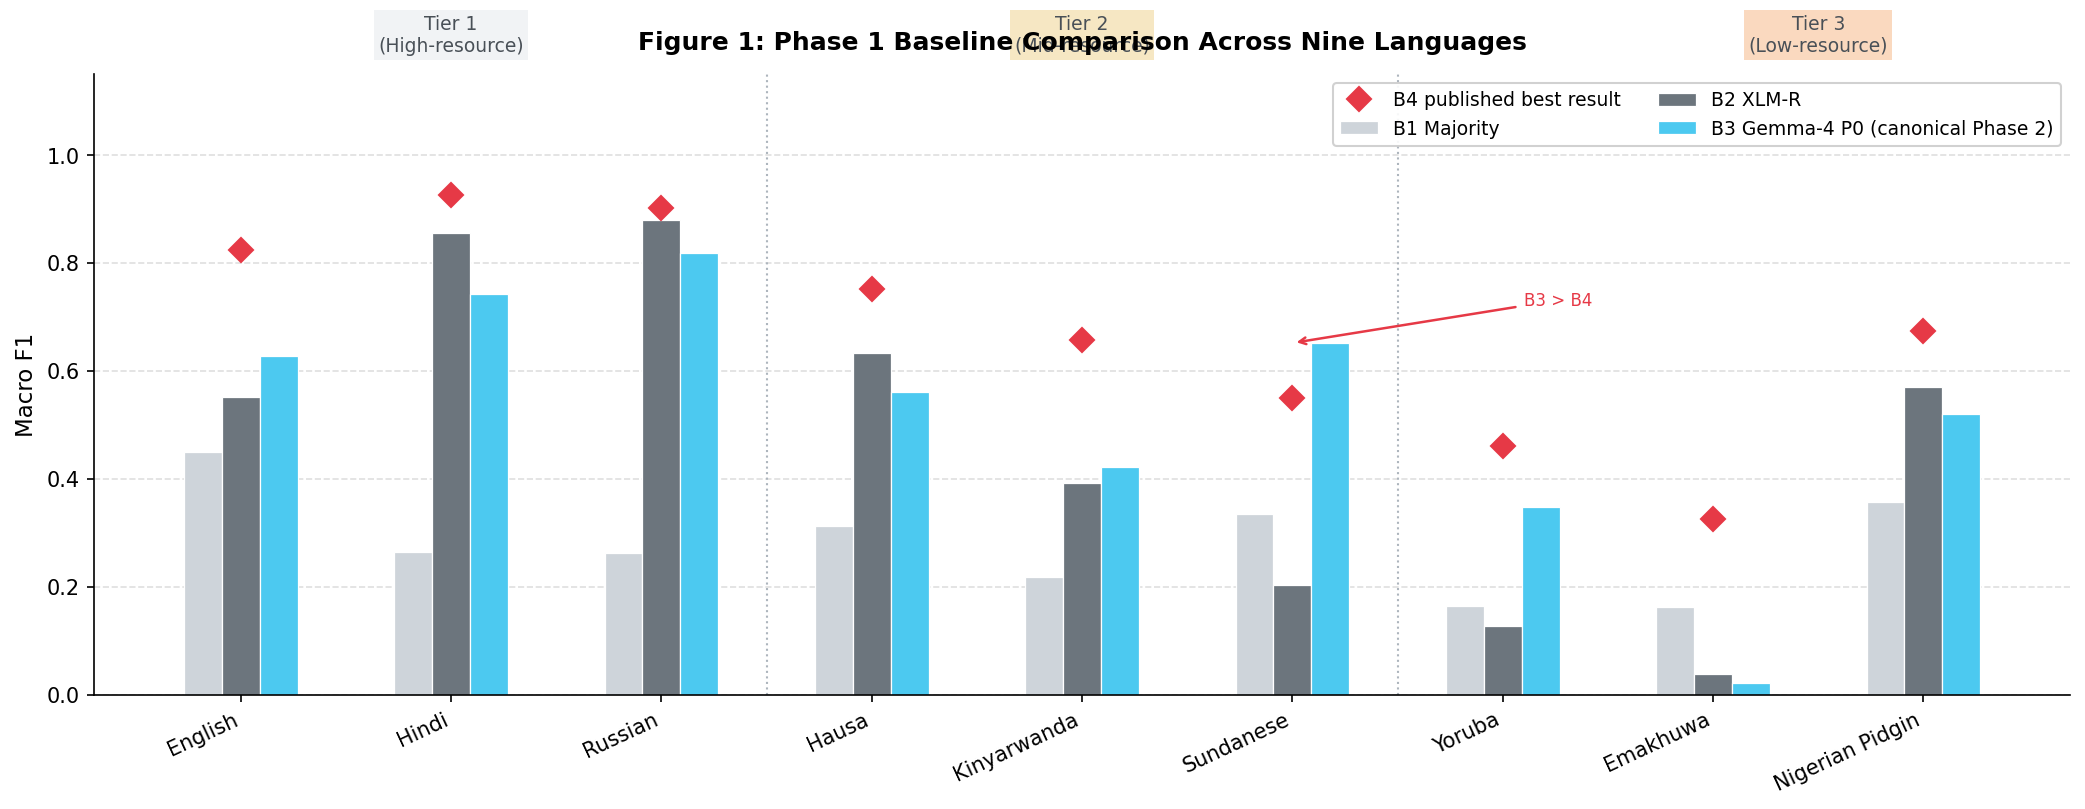

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST — Fig 1: Phase 1 Baseline Comparison
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5.5))

x = np.arange(len(LANG_ORDER))
w = 0.18

systems = [("b1","B1 Majority","#ced4da"), ("b2","B2 XLM-R","#6c757d"),
           ("b3","B3 Gemma-4 P0 (canonical Phase 2)","#4cc9f0")]

for i, (col, label, color) in enumerate(systems):
    vals = master[col].fillna(0).values
    bars = ax.bar(x + (i-1)*w, vals, w, label=label, color=color, edgecolor="white", linewidth=0.6)

# B4 as diamond markers
b4_vals = master["b4"].values
ax.plot(x, b4_vals, "D", color="#e63946", markersize=8, linewidth=0,
        label="B4 published best result", zorder=6)

# Tier dividers & labels
ax.axvline(x=2.5, color="#adb5bd", linewidth=1.0, linestyle=":")
ax.axvline(x=5.5, color="#adb5bd", linewidth=1.0, linestyle=":")

for tier_x, label in [(1, "Tier 1\n(High-resource)"), (4, "Tier 2\n(Mid-resource)"), (7.5, "Tier 3\n(Low-resource)")]:
    ax.text(tier_x, 1.03, label, ha="center", va="bottom",
            transform=ax.get_xaxis_transform(), fontsize=9, color="#495057",
            bbox=dict(fc=TIER_COLORS[1 if tier_x<3 else 2 if tier_x<6 else 3], ec="none", alpha=0.4, pad=2))

ax.set_xticks(x)
ax.set_xticklabels(LANG_NAMES, rotation=25, ha="right", fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Macro F1", fontsize=11)
ax.set_title("Figure 1: Phase 1 Baseline Comparison Across Nine Languages", fontsize=12, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9, ncol=2)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Annotate Sundanese B3 > B4
sun_idx = LANG_ORDER.index("sun")
sun_b3  = master.loc[master["code"]=="sun", "b3"].values[0]
ax.annotate("B3 > B4", xy=(sun_idx + 0*w, sun_b3), xytext=(sun_idx + 1.1, sun_b3 + 0.07),
            fontsize=8, color="#e63946",
            arrowprops=dict(arrowstyle="->", color="#e63946", lw=1.2))

plt.tight_layout()

path = f"{OUT_DIR}/fig1_phase1_baseline_comparison.png"
fig.savefig(path, dpi=200, bbox_inches="tight")

print(f"  ✓ Saved fig1_phase1_baseline_comparison.png")
plt.show()


## Fig 1 (Track C): Phase 1 Baseline - Cross-lingual

  ✓ Saved fig1_track_c_phase1_baseline.png


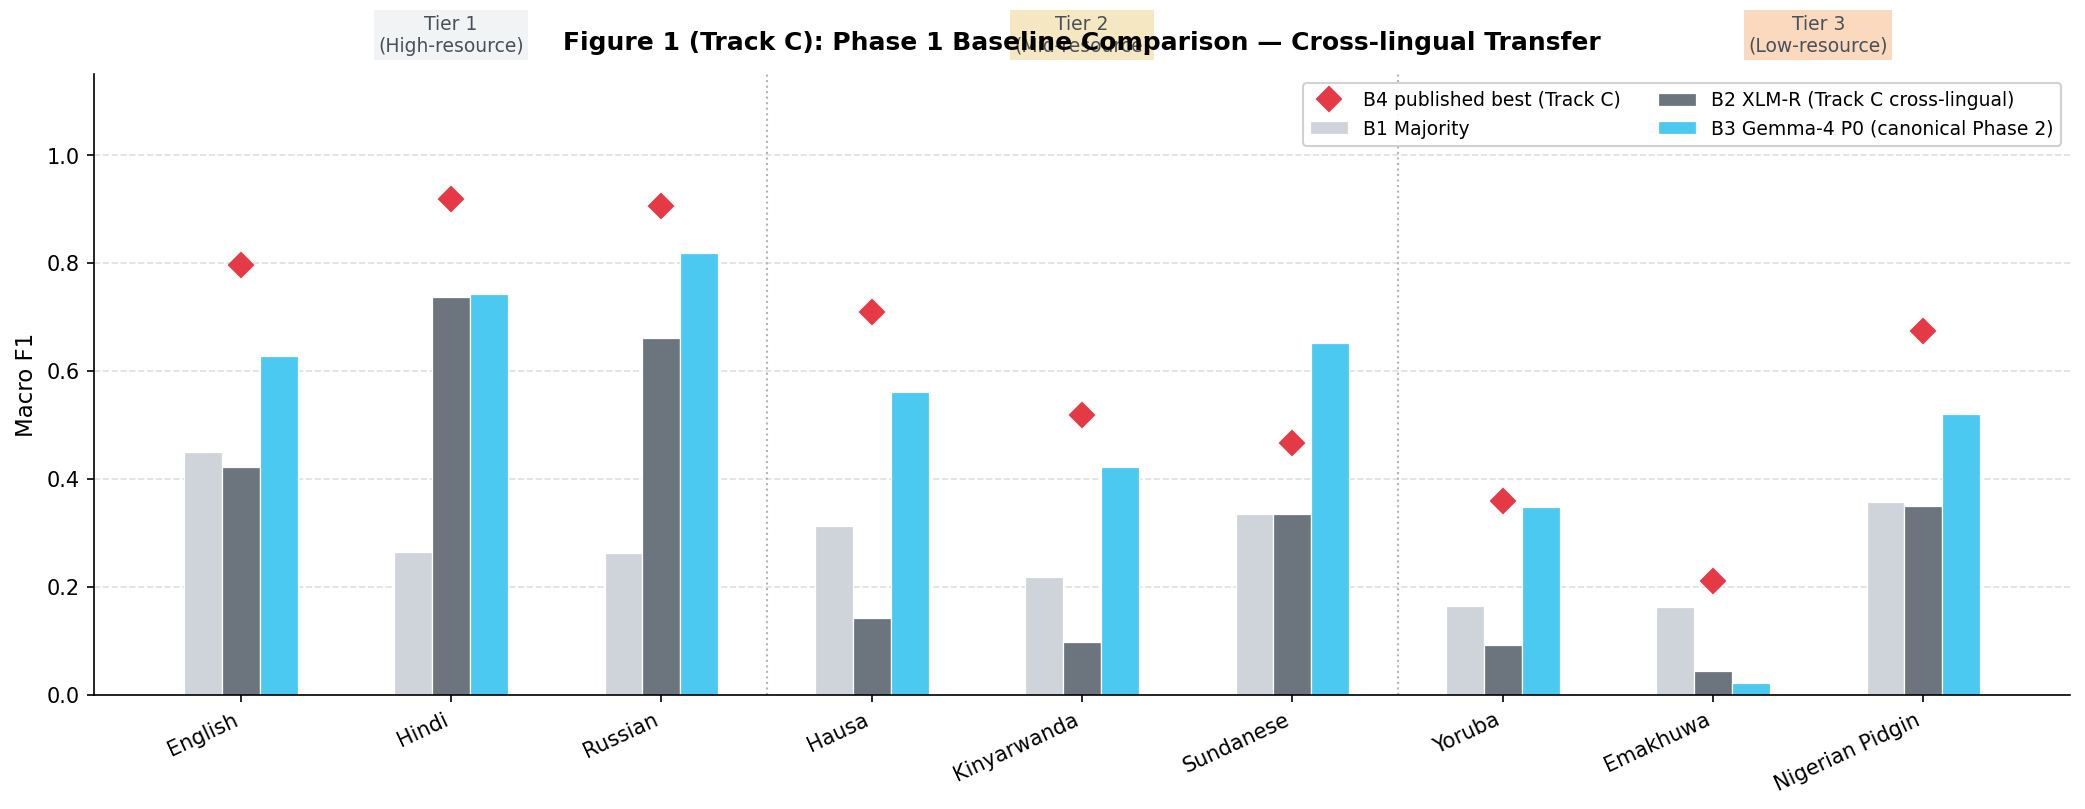

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST — Fig 1 (Track C): Phase 1 Baseline Comparison - Cross-lingual
# ─────────────────────────────────────────────────────────────────────────────

b1_tc  = [get_p1("majority", "track_c", code) or 0 for code in LANG_ORDER]
b2_tc  = [get_p1("xlmr",     "track_c", code) or 0 for code in LANG_ORDER]
b3_vals = master["b3"].fillna(0).values
b4_tc  = [PUBLISHED_B4_C[code] for code in LANG_ORDER]

fig, ax = plt.subplots(figsize=(14, 5.5))
x = np.arange(len(LANG_ORDER))
w = 0.18

for i, (vals, label, color) in enumerate(zip(
    [b1_tc, b2_tc, b3_vals],
    ["B1 Majority", "B2 XLM-R (Track C cross-lingual)", "B3 Gemma-4 P0 (canonical Phase 2)"],
    ["#ced4da", "#6c757d", "#4cc9f0"],
)):
    ax.bar(x + (i-1)*w, vals, w, label=label, color=color, edgecolor="white", linewidth=0.6)

ax.plot(x, b4_tc, "D", color="#e63946", markersize=8, linewidth=0,
        label="B4 published best (Track C)", zorder=6)

ax.axvline(x=2.5, color="#adb5bd", linewidth=1.0, linestyle=":")
ax.axvline(x=5.5, color="#adb5bd", linewidth=1.0, linestyle=":")
for tier_x, lbl in [(1,"Tier 1\n(High-resource)"), (4,"Tier 2\n(Mid-resource)"), (7.5,"Tier 3\n(Low-resource)")]:
    ax.text(tier_x, 1.03, lbl, ha="center", va="bottom",
            transform=ax.get_xaxis_transform(), fontsize=9, color="#495057",
            bbox=dict(fc=TIER_COLORS[1 if tier_x<3 else 2 if tier_x<6 else 3], ec="none", alpha=0.4, pad=2))

ax.set_xticks(x)
ax.set_xticklabels(LANG_NAMES, rotation=25, ha="right", fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Macro F1", fontsize=11)
ax.set_title("Figure 1 (Track C): Phase 1 Baseline Comparison — Cross-lingual Transfer",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9, ncol=2)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
path = f"{OUT_DIR}/fig1_track_c_phase1_baseline.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
print(f"  ✓ Saved fig1_track_c_phase1_baseline.png")
plt.show()


## 5.2 Figure 2 - Phase 2 prompt ablation


  ✓ Saved fig2_phase2_prompt_ablation.png


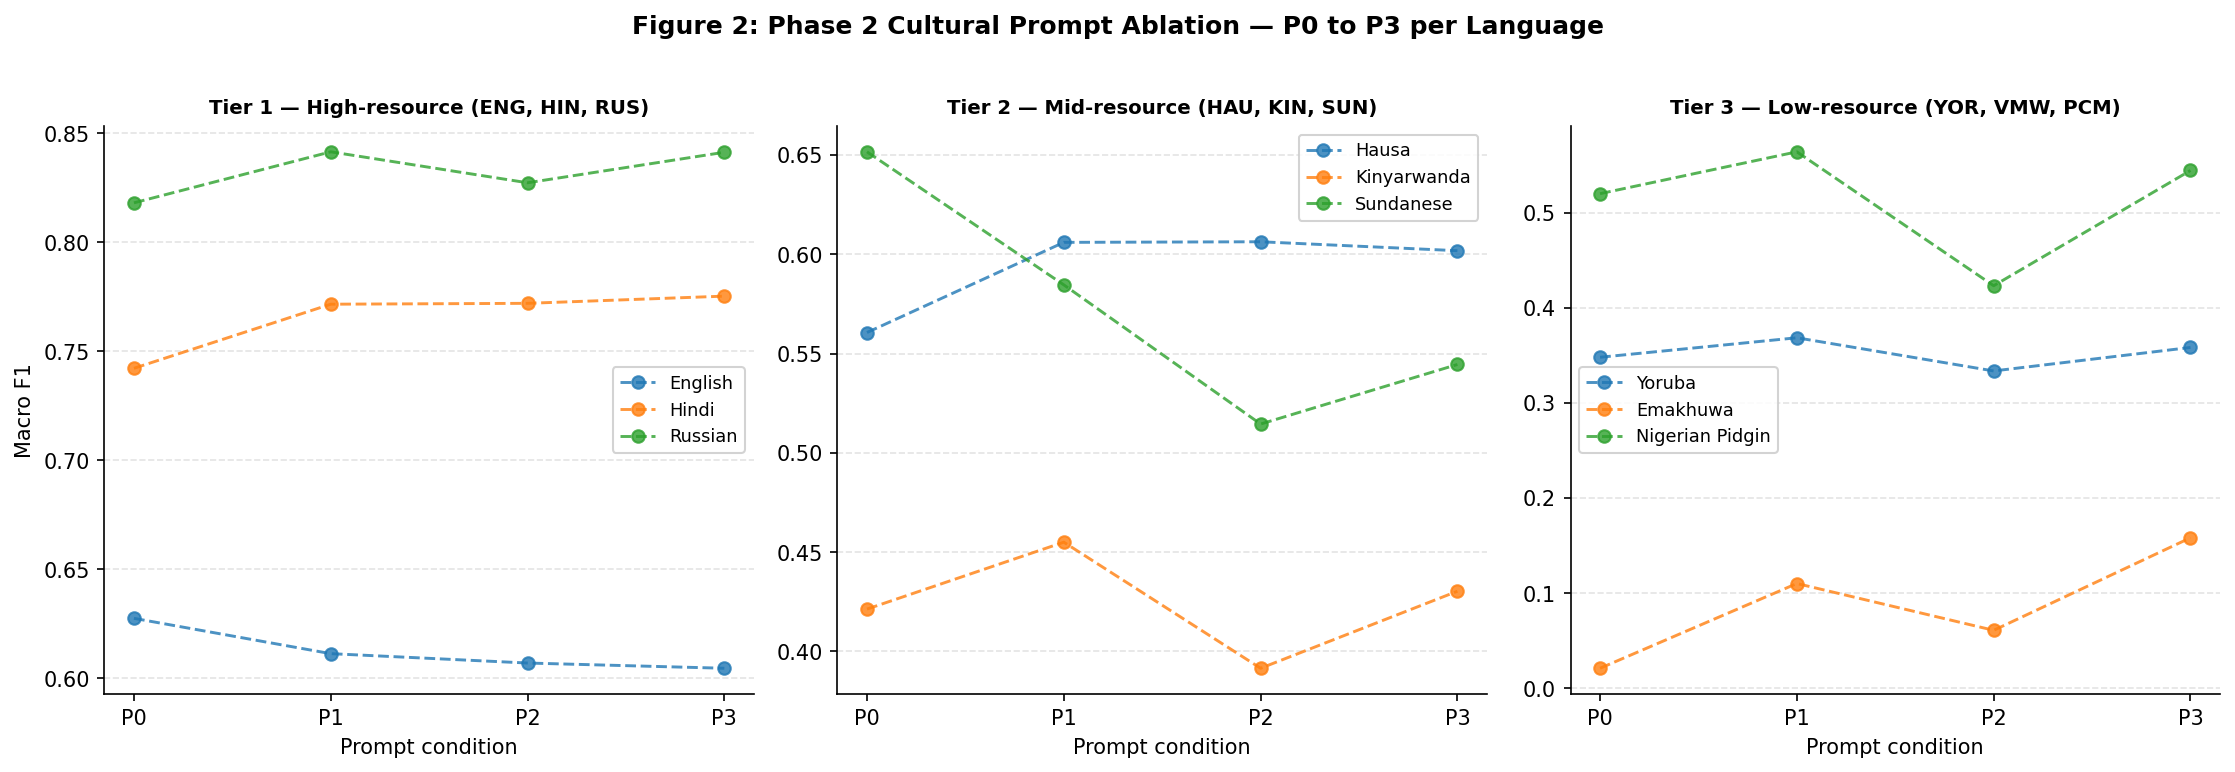


  Best prompt per language:
  English             best=P0  F1=0.627  Δ=0.000
  Hindi               best=P3  F1=0.775  Δ=0.033
  Russian             best=P1  F1=0.841  Δ=0.023
  Hausa               best=P2  F1=0.606  Δ=0.046
  Kinyarwanda         best=P1  F1=0.455  Δ=0.034
  Sundanese           best=P0  F1=0.652  Δ=0.000
  Yoruba              best=P1  F1=0.368  Δ=0.021
  Emakhuwa            best=P3  F1=0.158  Δ=0.137
  Nigerian Pidgin     best=P1  F1=0.564  Δ=0.044
  Statistical significance must be read from the adjusted-p table in Cell 13.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST — Fig 2: Phase 2 Prompt Ablation Line Chart
# ─────────────────────────────────────────────────────────────────────────────

# Build prompt-ablation DataFrame
prompt_rows = []
for code in LANG_ORDER:
    info = LANGUAGES[code]
    for p in ["p0","p1","p2","p3"]:
        val = get_p2(code, p)
        if val is not None:
            prompt_rows.append({"code": code, "language": info["name"],
                                 "tier": info["tier"], "prompt": p.upper(), "macro_f1": val})
prom_df = pd.DataFrame(prompt_rows)

# ── Grouped 3-row subplot (one per tier) ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
tier_labels = {1: "Tier 1 — High-resource (ENG, HIN, RUS)",
               2: "Tier 2 — Mid-resource (HAU, KIN, SUN)",
               3: "Tier 3 — Low-resource (YOR, VMW, PCM)"}
PROMPT_COLORS = {"P0":"#6c757d","P1":"#4361ee","P2":"#f72585","P3":"#06d6a0"}
markers       = {"P0":"o","P1":"s","P2":"^","P3":"D"}

for col_idx, tier in enumerate([1,2,3]):
    ax = axes[col_idx]
    tier_df = prom_df[prom_df["tier"] == tier]
    langs_in_tier = tier_df["language"].unique()

    for lang in langs_in_tier:
        lang_df = tier_df[tier_df["language"] == lang].sort_values("prompt")
        ax.plot(lang_df["prompt"], lang_df["macro_f1"], "o--",
                linewidth=1.4, markersize=6, label=lang, alpha=0.8)

    ax.set_title(tier_labels[tier], fontsize=9.5, fontweight="bold")
    ax.set_xlabel("Prompt condition", fontsize=10)
    if col_idx == 0:
        ax.set_ylabel("Macro F1", fontsize=10)
    ax.legend(fontsize=8.5, loc="best", framealpha=0.85)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelsize=10)

fig.suptitle("Figure 2: Phase 2 Cultural Prompt Ablation — P0 to P3 per Language",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
path = f"{OUT_DIR}/fig2_phase2_prompt_ablation.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
print(f"  ✓ Saved fig2_phase2_prompt_ablation.png")
plt.show()

# ── Summary table for caption ──────────────────────────────────────────────────
print("\n  Best prompt per language:")
for _, r in master.iterrows():
    print(
        f"  {r['language']:<18}  "
        f"best={r['p2_best_label']}  "
        f"F1={fmt(r['p2_best'])}  "
        f"Δ={fmt(r['p2_delta'])}"
    )
print("  Statistical significance must be read from the adjusted-p table in Cell 13.")


## 5.3 Figure 3a - Phase 3 XLM-R Track A results


  ✓ Saved fig3_phase3_heatmap.png


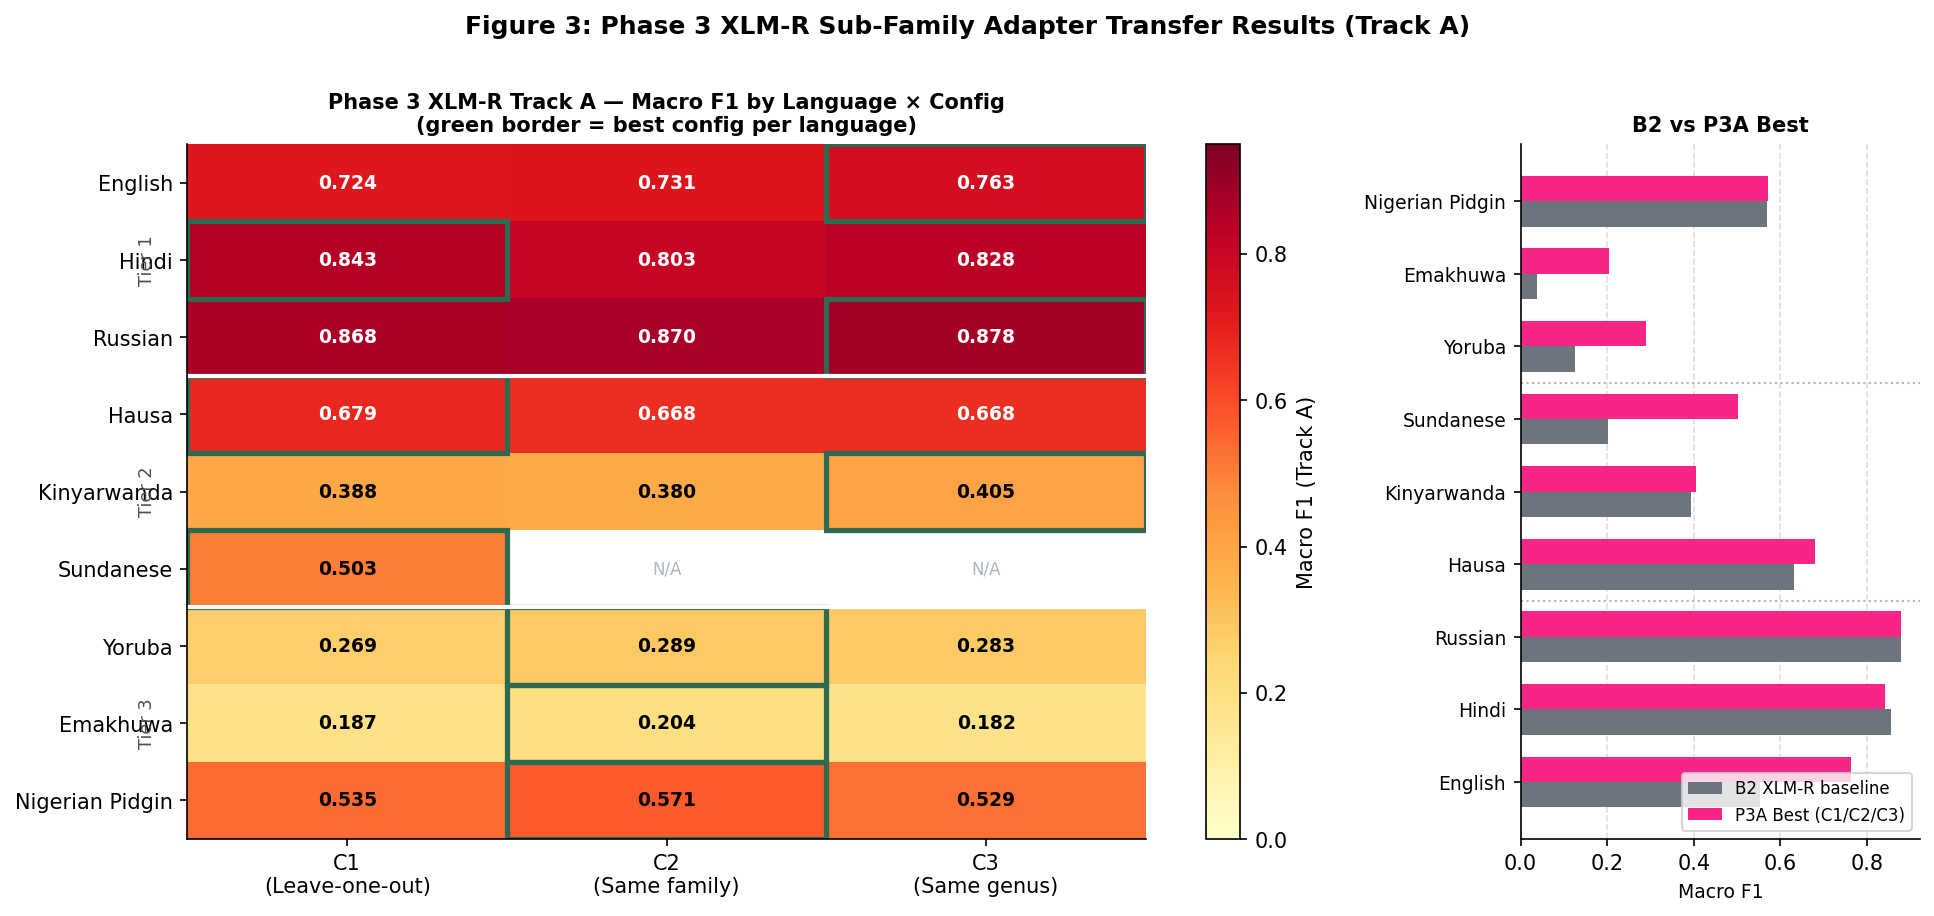

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST-— Fig 3: Phase 3 XLM-R Track A Heatmap (F1 by language × config)
# ─────────────────────────────────────────────────────────────────────────────

# Build matrix: langs × configs
hm_ta = np.full((len(LANG_ORDER), 3), np.nan)
for i, code in enumerate(LANG_ORDER):
    for j, cfg in enumerate(["C1","C2","C3"]):
        v = get_p3a(code, cfg)
        if v is not None:
            hm_ta[i, j] = v

# Mark B2 baseline for comparison
b2_vals = master["b2"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios":[3,1]})

# ── Left: heatmap ─────────────────────────────────────────────────────────────
im = ax1.imshow(hm_ta, cmap="YlOrRd", vmin=0.0, vmax=0.95, aspect="auto")
ax1.set_xticks(range(3))
ax1.set_xticklabels(["C1\n(Leave-one-out)", "C2\n(Same family)", "C3\n(Same genus)"], fontsize=10)
ax1.set_yticks(range(len(LANG_ORDER)))
ax1.set_yticklabels(LANG_NAMES, fontsize=10)

# Annotate each cell
for i in range(len(LANG_ORDER)):
    for j in range(3):
        val = hm_ta[i, j]
        if not np.isnan(val):
            txt_color = "white" if val > 0.65 else "black"
            ax1.text(j, i, f"{val:.3f}", ha="center", va="center",
                     fontsize=9, color=txt_color, fontweight="bold")
        else:
            ax1.text(j, i, "N/A", ha="center", va="center", fontsize=8, color="#adb5bd")

# Mark best config per language
for i, code in enumerate(LANG_ORDER):
    row_vals = hm_ta[i]
    if not np.all(np.isnan(row_vals)):
        best_j = np.nanargmax(row_vals)
        ax1.add_patch(plt.Rectangle((best_j-0.5, i-0.5), 1, 1,
                                     fill=False, edgecolor="#2d6a4f", linewidth=2.5))

# Tier dividers on y-axis
ax1.axhline(y=2.5, color="white", linewidth=2)
ax1.axhline(y=5.5, color="white", linewidth=2)
ax1.text(-0.6, 1, "Tier 1", ha="right", va="center", fontsize=8.5, color="#495057", rotation=90)
ax1.text(-0.6, 4, "Tier 2", ha="right", va="center", fontsize=8.5, color="#495057", rotation=90)
ax1.text(-0.6, 7, "Tier 3", ha="right", va="center", fontsize=8.5, color="#495057", rotation=90)

plt.colorbar(im, ax=ax1, label="Macro F1 (Track A)")
ax1.set_title("Phase 3 XLM-R Track A — Macro F1 by Language × Config\n(green border = best config per language)", fontsize=10, fontweight="bold")

# ── Right: B2 vs best P3A ──────────────────────────────────────────────────────
p3a_best_vals = np.nanmax(hm_ta, axis=1)
y = np.arange(len(LANG_ORDER))
ax2.barh(y, b2_vals, 0.35, label="B2 XLM-R baseline", color="#6c757d", left=0, align="center")
ax2.barh(y+0.35, p3a_best_vals, 0.35, label="P3A Best (C1/C2/C3)", color="#f72585", align="center")
ax2.set_yticks(y+0.175)
ax2.set_yticklabels(LANG_NAMES, fontsize=9)
ax2.set_xlabel("Macro F1", fontsize=9)
ax2.set_title("B2 vs P3A Best", fontsize=10, fontweight="bold")
ax2.legend(fontsize=8, loc="lower right")
ax2.xaxis.grid(True, linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)
ax2.axhline(y=2.5+0.175, color="#adb5bd", linewidth=1.0, linestyle=":")
ax2.axhline(y=5.5+0.175, color="#adb5bd", linewidth=1.0, linestyle=":")

fig.suptitle("Figure 3: Phase 3 XLM-R Sub-Family Adapter Transfer Results (Track A)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
path = f"{OUT_DIR}/fig3_phase3_heatmap.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
print(f"  ✓ Saved fig3_phase3_heatmap.png")
plt.show()


## Fig 3 (Track C): Phase 3 XLM-R Heatmap

  ✓ Saved fig3_track_c_xlmr_heatmap.png


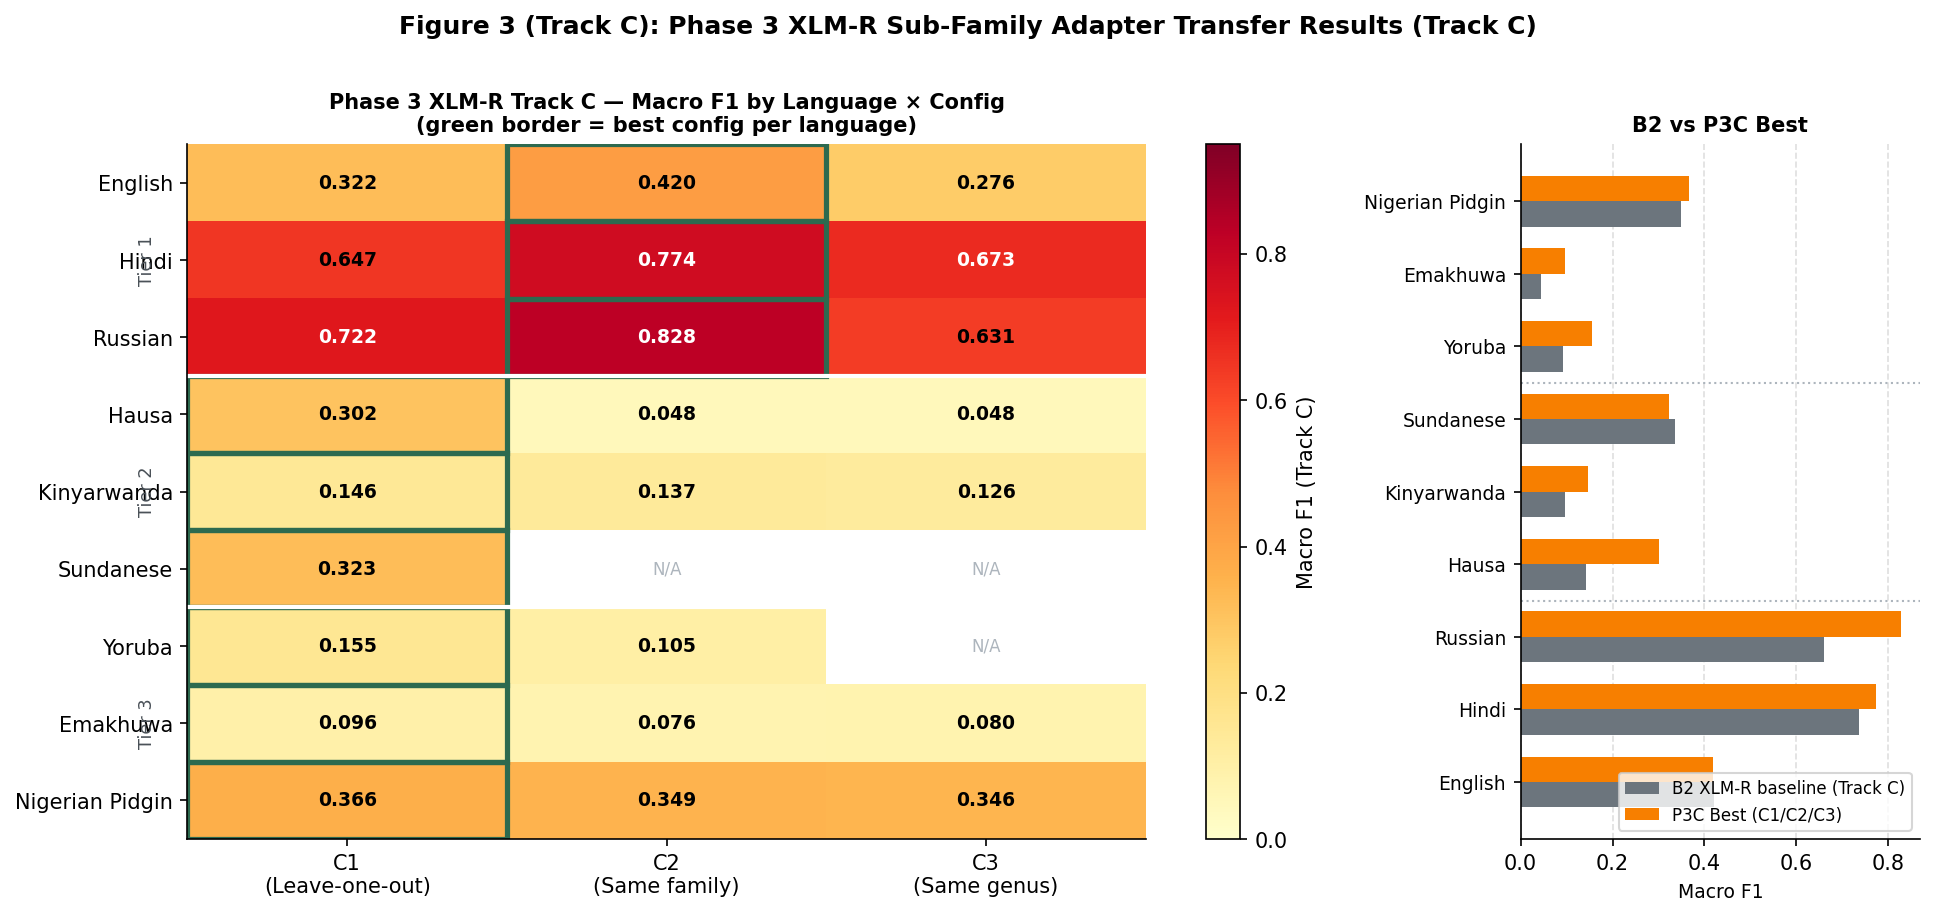

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST - Fig 3 (Track C): Phase 3 XLM-R Track C Heatmap
# ─────────────────────────────────────────────────────────────────────────────

hm_tc = np.full((len(LANG_ORDER), 3), np.nan)
for i, code in enumerate(LANG_ORDER):
    for j, cfg in enumerate(["C1","C2","C3"]):
        v = get_p3c(code, cfg)
        if v is not None:
            hm_tc[i, j] = v

b2_tc_vals = [get_p1("xlmr", "track_c", code) or 0 for code in LANG_ORDER]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios":[3,1]})

im = ax1.imshow(hm_tc, cmap="YlOrRd", vmin=0.0, vmax=0.95, aspect="auto")
ax1.set_xticks(range(3))
ax1.set_xticklabels(["C1\n(Leave-one-out)", "C2\n(Same family)", "C3\n(Same genus)"], fontsize=10)
ax1.set_yticks(range(len(LANG_ORDER)))
ax1.set_yticklabels(LANG_NAMES, fontsize=10)

for i in range(len(LANG_ORDER)):
    for j in range(3):
        val = hm_tc[i, j]
        if not np.isnan(val):
            txt_color = "white" if val > 0.65 else "black"
            ax1.text(j, i, f"{val:.3f}", ha="center", va="center",
                     fontsize=9, color=txt_color, fontweight="bold")
        else:
            ax1.text(j, i, "N/A", ha="center", va="center", fontsize=8, color="#adb5bd")

for i, code in enumerate(LANG_ORDER):
    row_vals = hm_tc[i]
    if not np.all(np.isnan(row_vals)):
        best_j = np.nanargmax(row_vals)
        ax1.add_patch(plt.Rectangle((best_j-0.5, i-0.5), 1, 1,
                                     fill=False, edgecolor="#2d6a4f", linewidth=2.5))

ax1.axhline(y=2.5, color="white", linewidth=2)
ax1.axhline(y=5.5, color="white", linewidth=2)
ax1.text(-0.6, 1, "Tier 1", ha="right", va="center", fontsize=8.5, color="#495057", rotation=90)
ax1.text(-0.6, 4, "Tier 2", ha="right", va="center", fontsize=8.5, color="#495057", rotation=90)
ax1.text(-0.6, 7, "Tier 3", ha="right", va="center", fontsize=8.5, color="#495057", rotation=90)
plt.colorbar(im, ax=ax1, label="Macro F1 (Track C)")
ax1.set_title("Phase 3 XLM-R Track C — Macro F1 by Language × Config\n(green border = best config per language)",
              fontsize=10, fontweight="bold")

p3c_best_vals = np.nanmax(hm_tc, axis=1)
y = np.arange(len(LANG_ORDER))
ax2.barh(y,       b2_tc_vals,    0.35, label="B2 XLM-R baseline (Track C)", color="#6c757d", align="center")
ax2.barh(y+0.35,  p3c_best_vals, 0.35, label="P3C Best (C1/C2/C3)",         color="#f77f00", align="center")
ax2.set_yticks(y+0.175)
ax2.set_yticklabels(LANG_NAMES, fontsize=9)
ax2.set_xlabel("Macro F1", fontsize=9)
ax2.set_title("B2 vs P3C Best", fontsize=10, fontweight="bold")
ax2.legend(fontsize=8, loc="lower right")
ax2.xaxis.grid(True, linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)
ax2.axhline(y=2.5+0.175, color="#adb5bd", linewidth=1.0, linestyle=":")
ax2.axhline(y=5.5+0.175, color="#adb5bd", linewidth=1.0, linestyle=":")

fig.suptitle("Figure 3 (Track C): Phase 3 XLM-R Sub-Family Adapter Transfer Results (Track C)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
path = f"{OUT_DIR}/fig3_track_c_xlmr_heatmap.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
print(f"  ✓ Saved fig3_track_c_xlmr_heatmap.png")
plt.show()


## 5.4 Figure 3b — Controlled XLM-R–SERENGETI comparison


Saved: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Visualisations/fig3b_backbone_comparison.png


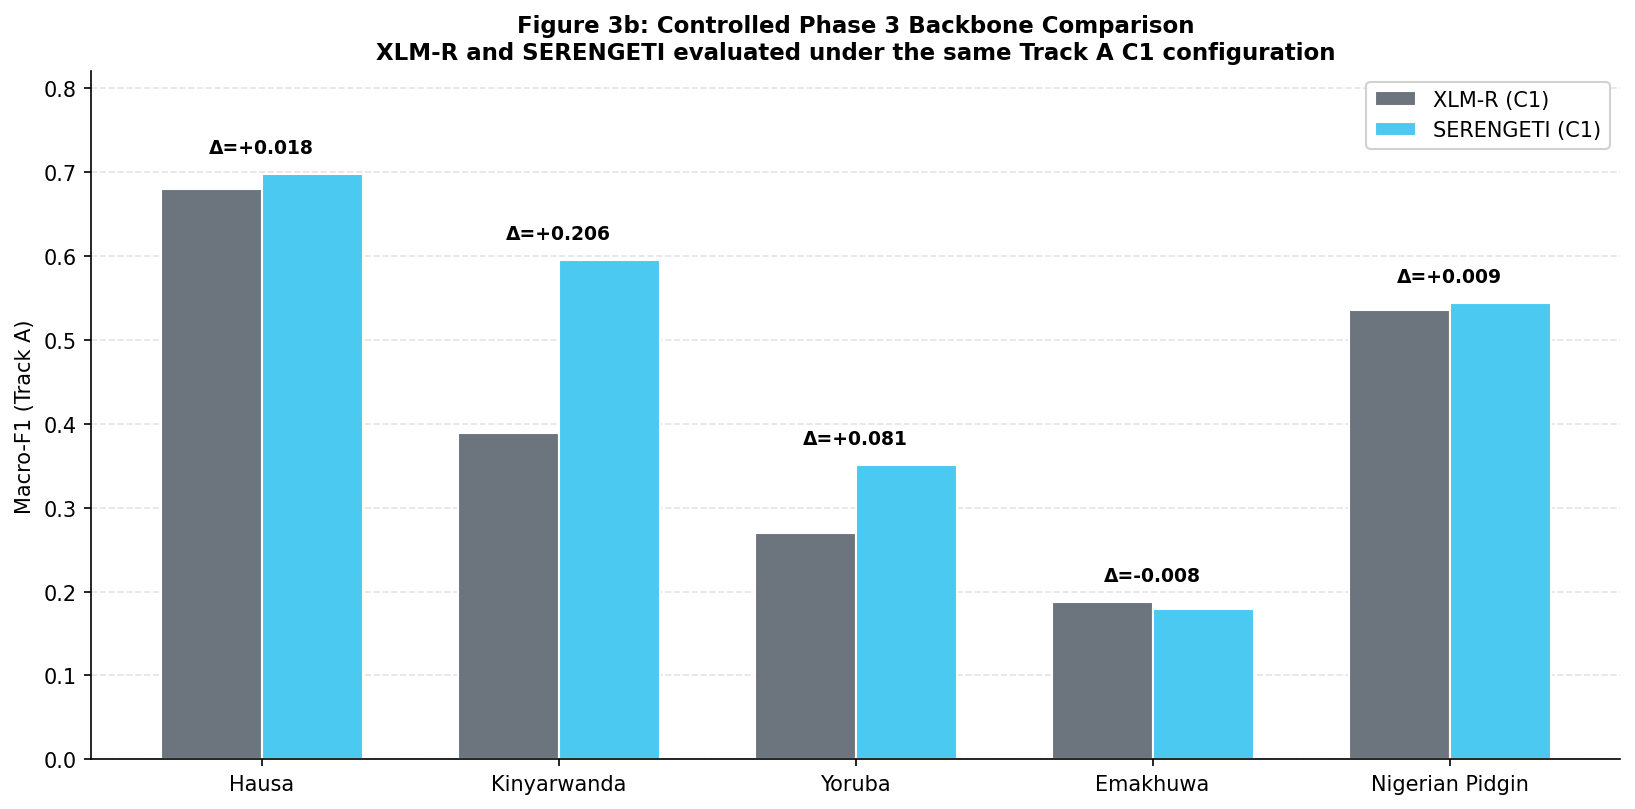

       language config  xlmr_macro_f1  serengeti_macro_f1  backbone_effect    winner
          Hausa     C1         0.6792              0.6974           0.0182 SERENGETI
    Kinyarwanda     C1         0.3883              0.5946           0.2063 SERENGETI
         Yoruba     C1         0.2693              0.3504           0.0811 SERENGETI
       Emakhuwa     C1         0.1870              0.1786          -0.0084     XLM-R
Nigerian Pidgin     C1         0.5350              0.5440           0.0089 SERENGETI


In [ ]:
# Controlled same-configuration comparison.
required_columns = {
    "lang", "language", "track", "config",
    "xlmr_macro_f1", "serengeti_macro_f1",
    "backbone_effect", "winner",
}
missing_columns = required_columns - set(p3_backbone.columns)
if missing_columns:
    raise ValueError(
        f"Backbone comparison missing columns: {sorted(missing_columns)}"
    )

# C1 is available for every applicable African-language target and provides
# one directly matched comparison per language.
matched_c1 = (
    p3_backbone[
        (p3_backbone["track"].astype(str).str.upper() == "A")
        & (p3_backbone["config"].astype(str).str.upper() == "C1")
    ]
    .copy()
    .set_index("lang")
    .reindex(["hau", "kin", "yor", "vmw", "pcm"])
    .reset_index()
)

if len(matched_c1) != 5:
    raise ValueError(f"Expected 5 Track A C1 backbone comparison rows, got {len(matched_c1)}")

# Warn on missing SERENGETI values rather than crashing (HAU C2/C3 are legitimately N/A)
_missing = matched_c1[["xlmr_macro_f1", "serengeti_macro_f1", "backbone_effect"]].isna().any(axis=1)

if _missing.any():
    print(f"  NOTE: {_missing.sum()} backbone comparison row(s) have NaN SERENGETI values (N/A configs) and will be skipped in the plot.")
matched_c1 = matched_c1.dropna(subset=["xlmr_macro_f1", "serengeti_macro_f1"])

figure_path = f"{OUT_DIR}/fig3b_backbone_comparison.png"

if should_generate(figure_path):
    x = np.arange(len(matched_c1))
    width = 0.34

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.bar(
        x - width / 2,
        matched_c1["xlmr_macro_f1"],
        width,
        label="XLM-R (C1)",
        color="#6c757d",
        edgecolor="white",
    )
    ax.bar(
        x + width / 2,
        matched_c1["serengeti_macro_f1"],
        width,
        label="SERENGETI (C1)",
        color="#4cc9f0",
        edgecolor="white",
    )

    for index, row in matched_c1.iterrows():
        highest = max(row["xlmr_macro_f1"], row["serengeti_macro_f1"])
        ax.text(
            index,
            highest + 0.025,
            f"Δ={row['backbone_effect']:+.3f}",
            ha="center",
            fontsize=9,
            fontweight="bold",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(matched_c1["language"], fontsize=10)
    ax.set_ylabel("Macro-F1 (Track A)")
    ax.set_ylim(0, 0.82)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(framealpha=0.9)

    ax.set_title(
        "Figure 3b: Controlled Phase 3 Backbone Comparison\n"
        "XLM-R and SERENGETI evaluated under the same Track A C1 configuration",
        fontsize=11,
        fontweight="bold",
    )

    plt.tight_layout()
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {figure_path}")
    plt.show()

print(
    matched_c1[
        [
            "language", "config", "xlmr_macro_f1",
            "serengeti_macro_f1", "backbone_effect", "winner",
        ]
    ].to_string(index=False)
)


## Fig 3b (Track C): Backbone Comparison - Track C

Saved: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Visualisations/fig3b_track_c_backbone_comparison.png


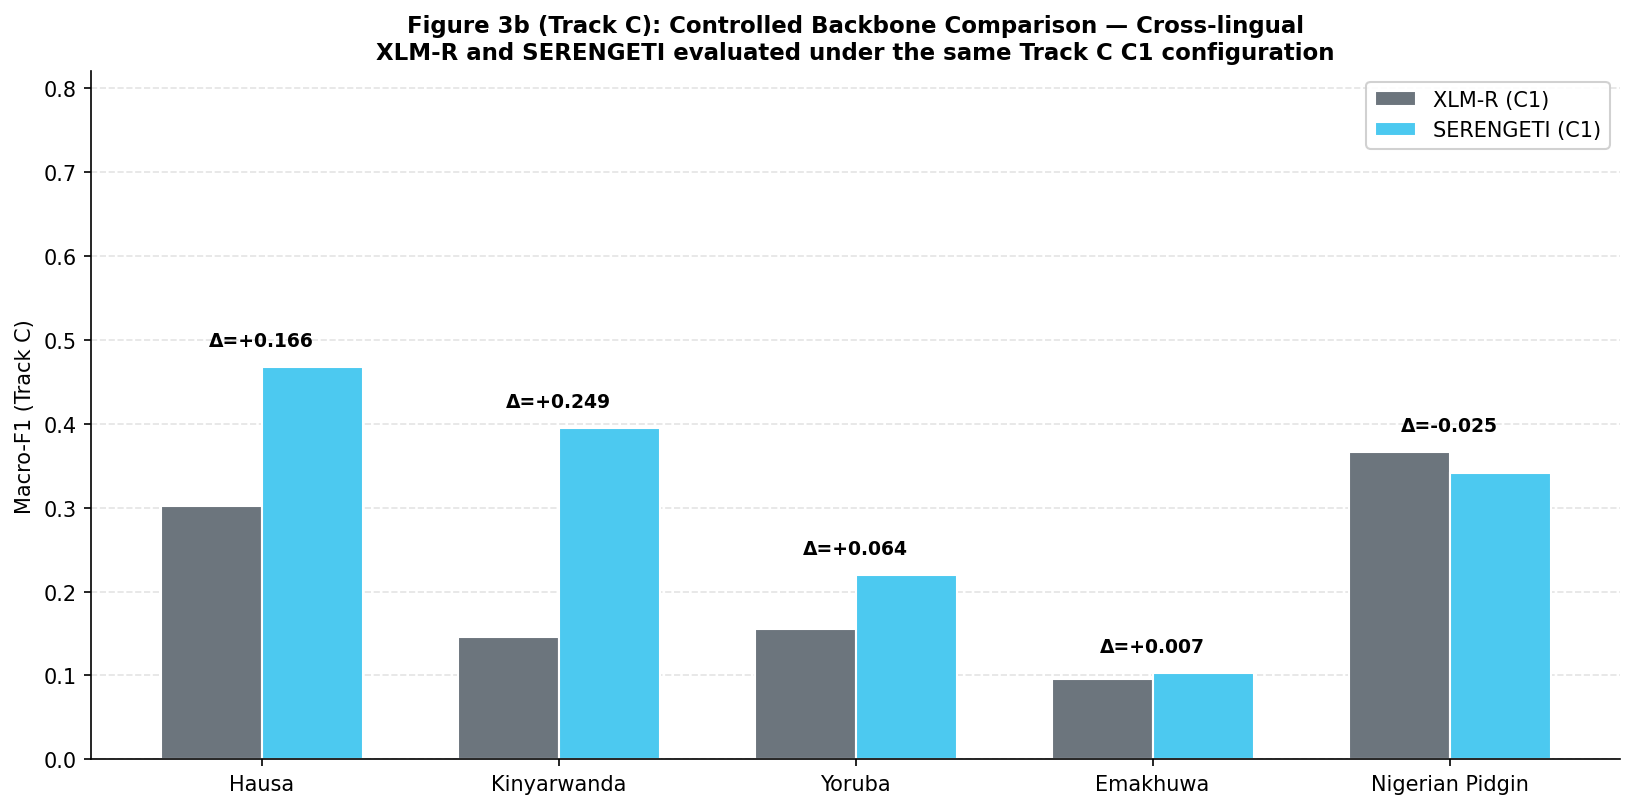

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST - Fig 3b (Track C): Backbone Comparison - Cross-lingual C1
# ─────────────────────────────────────────────────────────────────────────────

matched_c1_tc = (
    p3_backbone[
        (p3_backbone["track"].astype(str).str.upper() == "C")
        & (p3_backbone["config"].astype(str).str.upper() == "C1")
    ]
    .copy()
    .set_index("lang")
    .reindex(["hau", "kin", "yor", "vmw", "pcm"])
    .reset_index()
)

_missing_tc = matched_c1_tc[["xlmr_macro_f1", "serengeti_macro_f1", "backbone_effect"]].isna().any(axis=1)
if _missing_tc.any():
    print(f"  NOTE: {_missing_tc.sum()} Track C backbone row(s) have NaN values and will be skipped.")

matched_c1_tc = matched_c1_tc.dropna(subset=["xlmr_macro_f1", "serengeti_macro_f1"])

figure_path_tc = f"{OUT_DIR}/fig3b_track_c_backbone_comparison.png"

if should_generate(figure_path_tc) and len(matched_c1_tc) > 0:
    x = np.arange(len(matched_c1_tc))
    width = 0.34
    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.bar(x - width/2, matched_c1_tc["xlmr_macro_f1"],     width, label="XLM-R (C1)",     color="#6c757d", edgecolor="white")
    ax.bar(x + width/2, matched_c1_tc["serengeti_macro_f1"], width, label="SERENGETI (C1)", color="#4cc9f0", edgecolor="white")

    for index, row in matched_c1_tc.iterrows():
        highest = max(row["xlmr_macro_f1"], row["serengeti_macro_f1"])
        ax.text(index, highest + 0.025, f"Δ={row['backbone_effect']:+.3f}",
                ha="center", fontsize=9, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(matched_c1_tc["language"], fontsize=10)
    ax.set_ylabel("Macro-F1 (Track C)")
    ax.set_ylim(0, 0.82)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(framealpha=0.9)

    ax.set_title("Figure 3b (Track C): Controlled Backbone Comparison — Cross-lingual\n"
                 "XLM-R and SERENGETI evaluated under the same Track C C1 configuration",
                 fontsize=11, fontweight="bold")

    plt.tight_layout()
    fig.savefig(figure_path_tc, dpi=200, bbox_inches="tight")
    print(f"Saved: {figure_path_tc}")
    plt.show()

else:
    print("  NOTE: No Track C C1 matched rows available — backbone figure skipped.")


## 5.5 Figure 3c - Phase 3 SERENGETI Track A results


Saved: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Visualisations/fig3c_serengeti_heatmap.png


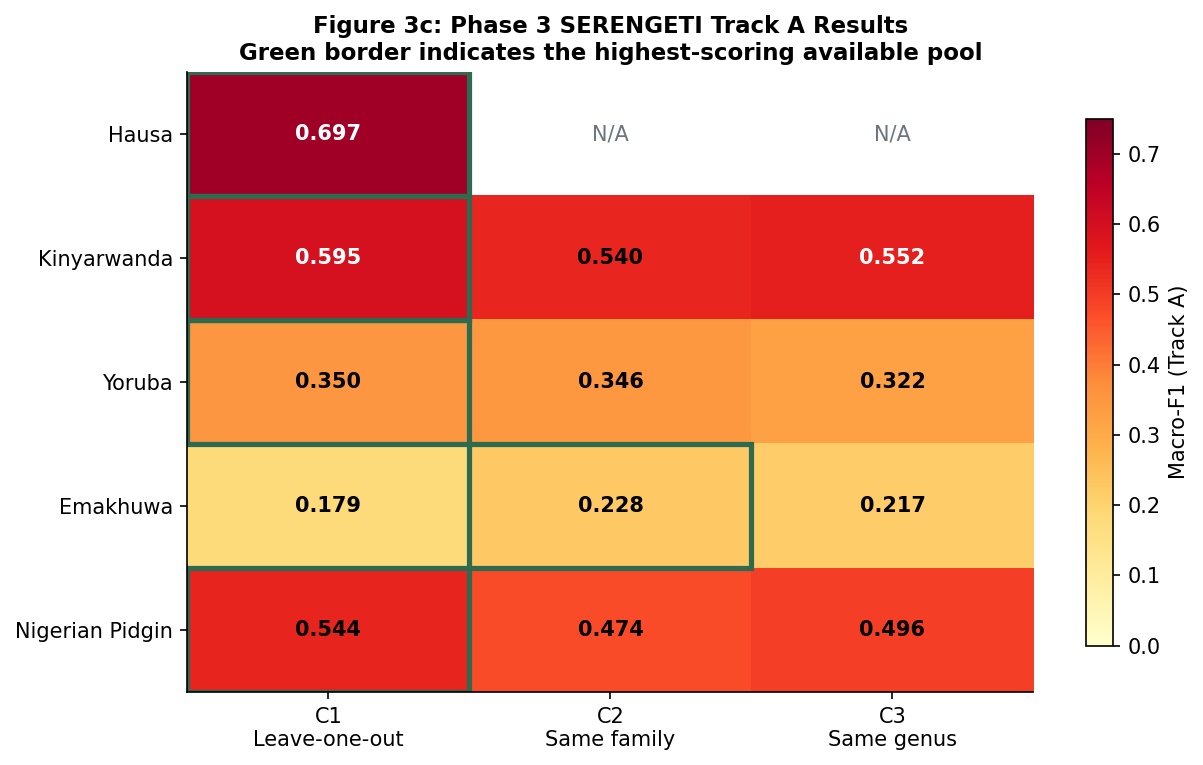

In [ ]:
tier23_codes = ["hau", "kin", "yor", "vmw", "pcm"]
tier23_names = [LANGUAGES[code]["name"] for code in tier23_codes]
configs = ["C1", "C2", "C3"]

serengeti_matrix = np.full((len(tier23_codes), len(configs)), np.nan)
for row_index, code_value in enumerate(tier23_codes):
    for column_index, config_value in enumerate(configs):
        score = get_srng_a(code_value, config_value)
        if score is not None:
            serengeti_matrix[row_index, column_index] = score

figure_path = f"{OUT_DIR}/fig3c_serengeti_heatmap.png"

if should_generate(figure_path):
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    image = ax.imshow(
        serengeti_matrix,
        cmap="YlOrRd",
        vmin=0,
        vmax=0.75,
        aspect="auto",
    )
    ax.set_xticks(range(3))
    ax.set_xticklabels(
        ["C1\nLeave-one-out", "C2\nSame family", "C3\nSame genus"],
        fontsize=10,
    )
    ax.set_yticks(range(len(tier23_codes)))
    ax.set_yticklabels(tier23_names, fontsize=10)

    for row_index in range(len(tier23_codes)):
        for column_index in range(len(configs)):
            score = serengeti_matrix[row_index, column_index]
            if np.isnan(score):
                ax.text(
                    column_index, row_index, "N/A",
                    ha="center", va="center", color="#6c757d",
                )
            else:
                text_colour = "white" if score > 0.55 else "black"
                ax.text(
                    column_index, row_index, f"{score:.3f}",
                    ha="center", va="center",
                    color=text_colour, fontweight="bold",
                )

        row = serengeti_matrix[row_index]
        if not np.all(np.isnan(row)):
            best_column = int(np.nanargmax(row))
            ax.add_patch(
                plt.Rectangle(
                    (best_column - 0.5, row_index - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="#2d6a4f",
                    linewidth=2.5,
                )
            )

    plt.colorbar(image, ax=ax, label="Macro-F1 (Track A)", shrink=0.85)

    ax.set_title(
        "Figure 3c: Phase 3 SERENGETI Track A Results\n"
        "Green border indicates the highest-scoring available pool",
        fontsize=11,
        fontweight="bold",
    )

    plt.tight_layout()
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")

    print(f"Saved: {figure_path}")
    plt.show()


## Fig 3c (Track C): SERENGETI Heatmap

Saved: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Visualisations/fig3c_track_c_serengeti_heatmap.png


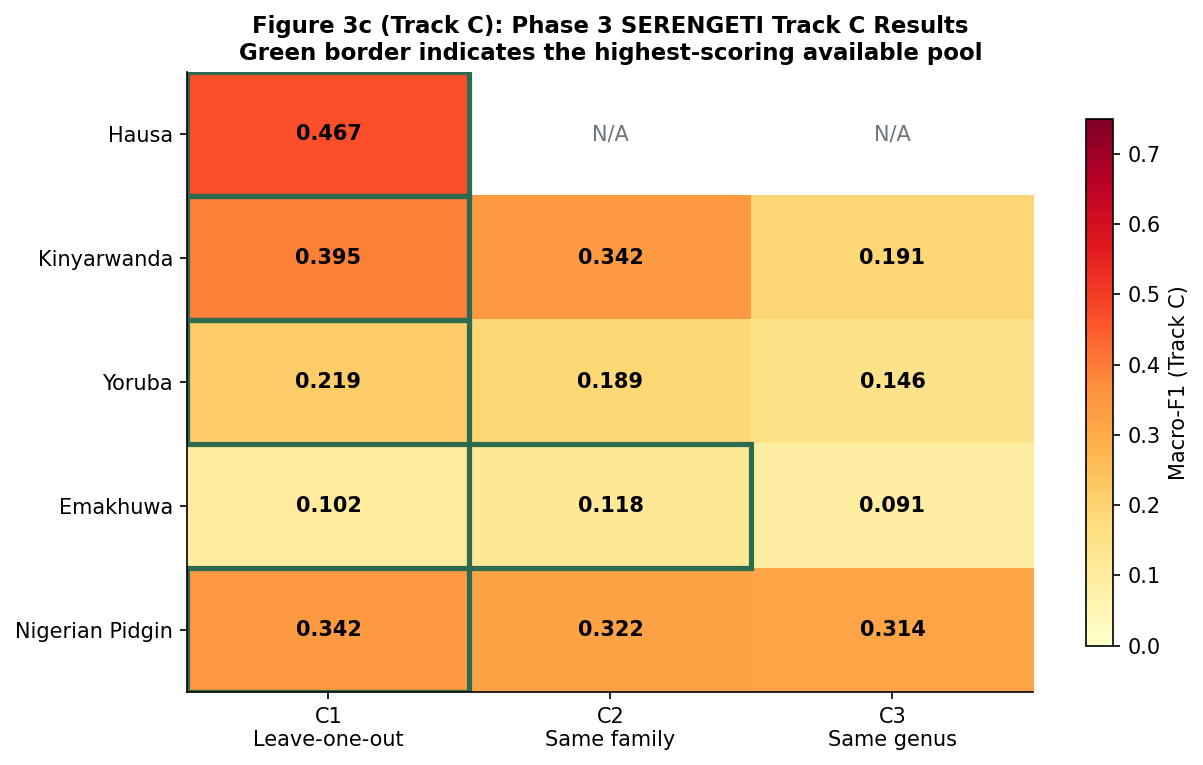

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST - Fig 3c (Track C): SERENGETI Track C Heatmap
# ─────────────────────────────────────────────────────────────────────────────

tier23_codes  = ["hau", "kin", "yor", "vmw", "pcm"]
tier23_names  = [LANGUAGES[code]["name"] for code in tier23_codes]
configs       = ["C1", "C2", "C3"]

srng_matrix_tc = np.full((len(tier23_codes), len(configs)), np.nan)
for ri, code in enumerate(tier23_codes):
    for ci, cfg in enumerate(configs):
        v = get_srng_c(code, cfg)
        if v is not None:
            srng_matrix_tc[ri, ci] = v

figure_path_srng_tc = f"{OUT_DIR}/fig3c_track_c_serengeti_heatmap.png"

if should_generate(figure_path_srng_tc):
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    image = ax.imshow(srng_matrix_tc, cmap="YlOrRd", vmin=0, vmax=0.75, aspect="auto")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["C1\nLeave-one-out", "C2\nSame family", "C3\nSame genus"], fontsize=10)
    ax.set_yticks(range(len(tier23_codes)))
    ax.set_yticklabels(tier23_names, fontsize=10)

    for ri in range(len(tier23_codes)):
        for ci in range(len(configs)):
            score = srng_matrix_tc[ri, ci]
            if np.isnan(score):
                ax.text(ci, ri, "N/A", ha="center", va="center", color="#6c757d")
            else:
                tc = "white" if score > 0.55 else "black"
                ax.text(ci, ri, f"{score:.3f}", ha="center", va="center",
                        color=tc, fontweight="bold")
        row = srng_matrix_tc[ri]

        if not np.all(np.isnan(row)):
            best_ci = int(np.nanargmax(row))
            ax.add_patch(plt.Rectangle((best_ci-0.5, ri-0.5), 1, 1,
                                       fill=False, edgecolor="#2d6a4f", linewidth=2.5))

    plt.colorbar(image, ax=ax, label="Macro-F1 (Track C)", shrink=0.85)
    ax.set_title("Figure 3c (Track C): Phase 3 SERENGETI Track C Results\n"
                 "Green border indicates the highest-scoring available pool",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    fig.savefig(figure_path_srng_tc, dpi=200, bbox_inches="tight")
    print(f"Saved: {figure_path_srng_tc}")
    plt.show()


## 5.6 Figure 4 — Phase 4 within-Gemma 2×2 ablation


  ✓ Saved fig4_phase4_ablation.png


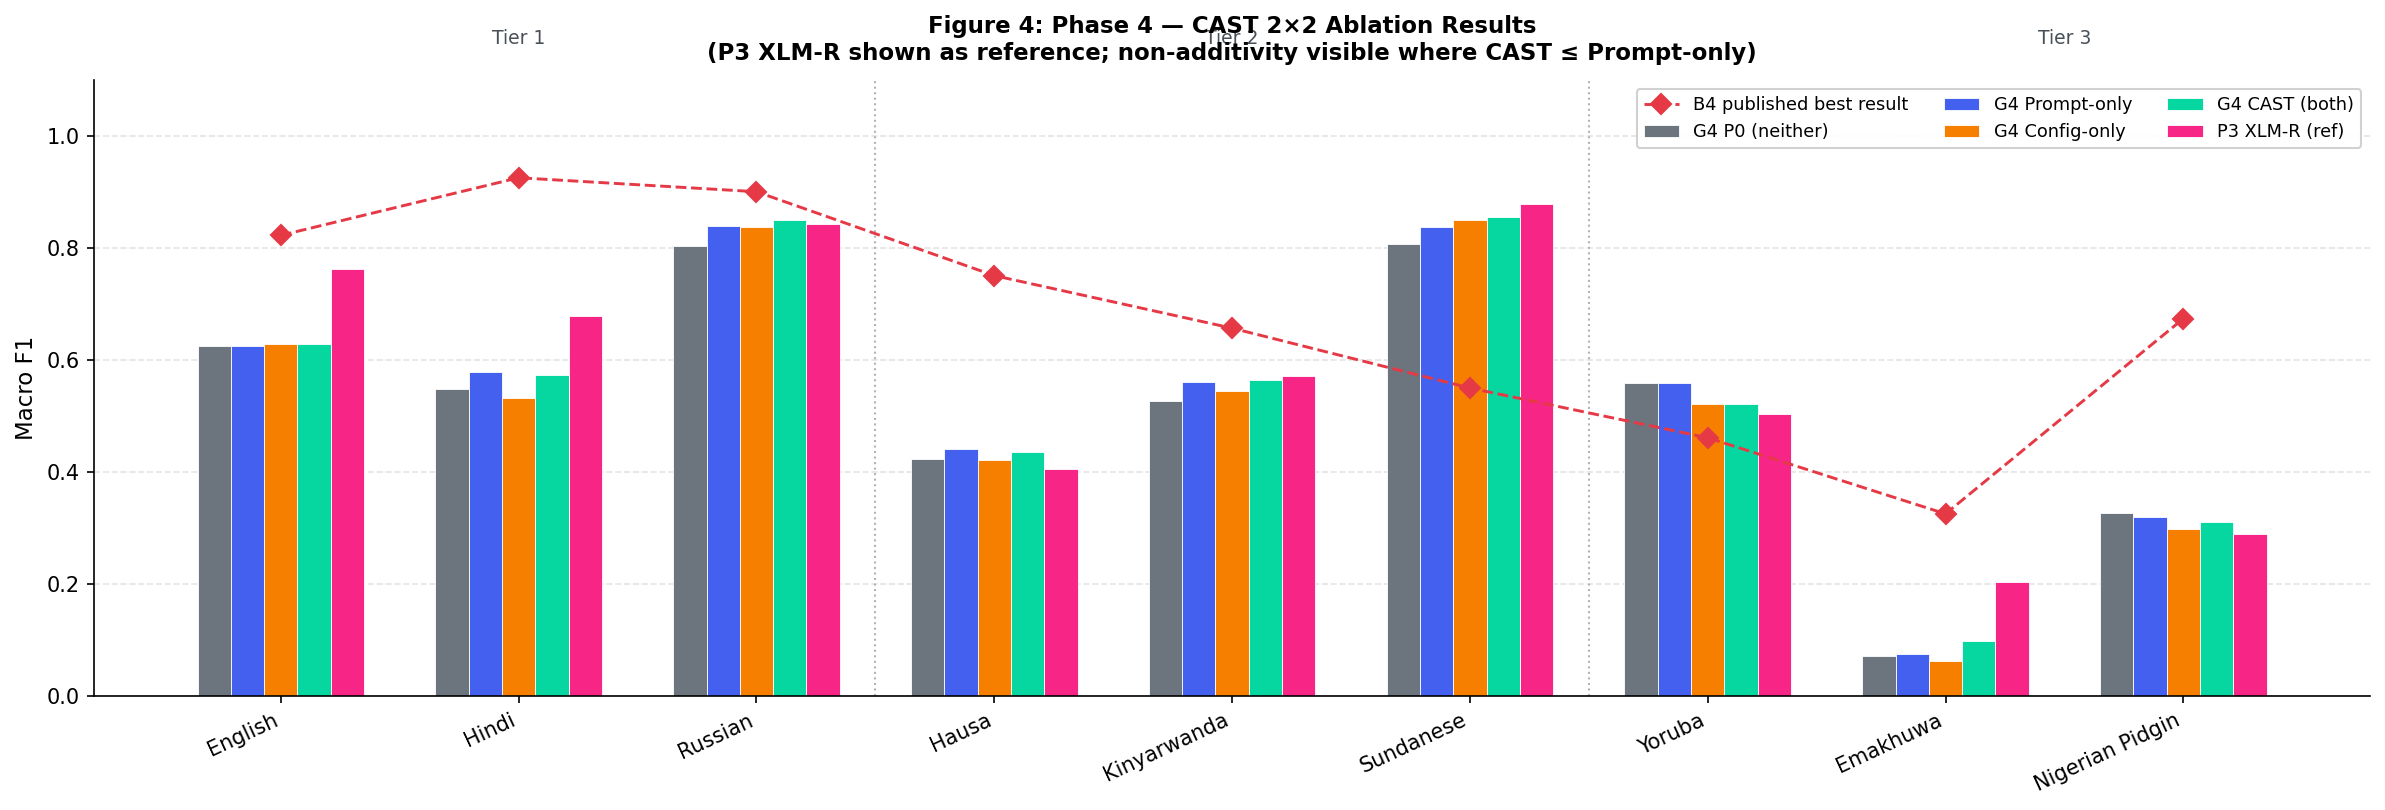

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST - Fig 4: Phase 4 2×2 Ablation Bar Chart
# ─────────────────────────────────────────────────────────────────────────────

# Expected columns from Phase4/phase4_gemma4_ablation_table.csv:
#   Language, Tier, Best-P, Best-C,
#   G4-P0(neither), G4-Prompt-only, G4-Config-only, G4-CAST(both),
#   B2-XLMR(ref), P3-Xfer(ref), B4-Published, vs-B4, Additive?

if p4_ablation.empty:
    print(" Phase 4 ablation CSV not found - rebuilding from raw result files")
    abl_df = build_phase4_ablation_fallback()
else:
    abl_df = p4_ablation.copy()
    # Normalise column names
    col_map = {}
    for col in abl_df.columns:
        cl = col.lower()
        if "neither" in cl or (cl.startswith("g4") and "p0" in cl and "prompt" not in cl and "config" not in cl and "cast" not in cl):
            col_map[col] = "G4-P0"
        elif "prompt-only" in cl or "prompt only" in cl:
            col_map[col] = "G4-Prompt"
        elif "config-only" in cl or "config only" in cl:
            col_map[col] = "G4-Config"
        elif "cast" in cl and ("both" in cl or cl == "g4-cast"):
            col_map[col] = "G4-CAST"
        elif "xfer" in cl or "transfer" in cl or "p3" in cl.lower():
            col_map[col] = "P3-XLM-ref"
        elif col.lower() == "language":
            col_map[col] = "Language"
        elif col.lower() == "tier":
            col_map[col] = "Tier"
        elif "b4" in cl and "published" in cl:
            col_map[col] = "B4"

    abl_df = abl_df.rename(columns=col_map)

    for needed in ["G4-P0","G4-Prompt","G4-Config","G4-CAST","P3-XLM-ref","B4"]:
        if needed not in abl_df.columns:
            abl_df[needed] = np.nan

# ── Plot ──────────────────────────────────────────────────────────────────────
conditions = ["G4-P0","G4-Prompt","G4-Config","G4-CAST","P3-XLM-ref"]
colors      = ["#6c757d","#4361ee","#f77f00","#06d6a0","#f72585"]
labels      = ["G4 P0 (neither)","G4 Prompt-only","G4 Config-only","G4 CAST (both)","P3 XLM-R (ref)"]

x = np.arange(len(LANG_ORDER))
n = len(conditions)
w = 0.14

fig, ax = plt.subplots(figsize=(16, 5.5))

for i, (cond, color, label) in enumerate(zip(conditions, colors, labels)):
    if cond in abl_df.columns:
        vals = abl_df[cond].fillna(0).values
    else:
        vals = np.zeros(len(LANG_ORDER))
    offset = (i - n/2 + 0.5) * w
    ax.bar(x + offset, vals, w, label=label, color=color, edgecolor="white", linewidth=0.4)

# B4 line
b4_line = [PUBLISHED_B4[c] for c in LANG_ORDER]
ax.plot(x, b4_line, "D--", color="#e63946", linewidth=1.4, markersize=7,
        label="B4 published best result", zorder=6)

ax.axvline(2.5, color="#adb5bd", linewidth=1, linestyle=":")
ax.axvline(5.5, color="#adb5bd", linewidth=1, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels(LANG_NAMES, rotation=25, ha="right", fontsize=10)
ax.set_ylim(0, 1.10)

ax.set_ylabel("Macro F1", fontsize=11)
ax.set_title("Figure 4: Phase 4 — CAST 2×2 Ablation Results\n"
             "(P3 XLM-R shown as reference; non-additivity visible where CAST ≤ Prompt-only)",
             fontsize=11, fontweight="bold", pad=10)

ax.legend(loc="upper right", fontsize=8.5, framealpha=0.9, ncol=3)
ax.yaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

# Tier labels
for tier_x, label in [(1,"Tier 1"), (4,"Tier 2"), (7.5,"Tier 3")]:
    ax.text(tier_x, 1.06, label, ha="center", fontsize=9,
            transform=ax.get_xaxis_transform(), color="#495057")

plt.tight_layout()
path = f"{OUT_DIR}/fig4_phase4_ablation.png"

fig.savefig(path, dpi=200, bbox_inches="tight")

print(f"  ✓ Saved fig4_phase4_ablation.png")
plt.show()


## 5.7 Figure 5 - Best observed system versus published best result


✓  Best-system table rebuilt from current raw result files.
  ✓ Saved fig5_best_system_summary.png


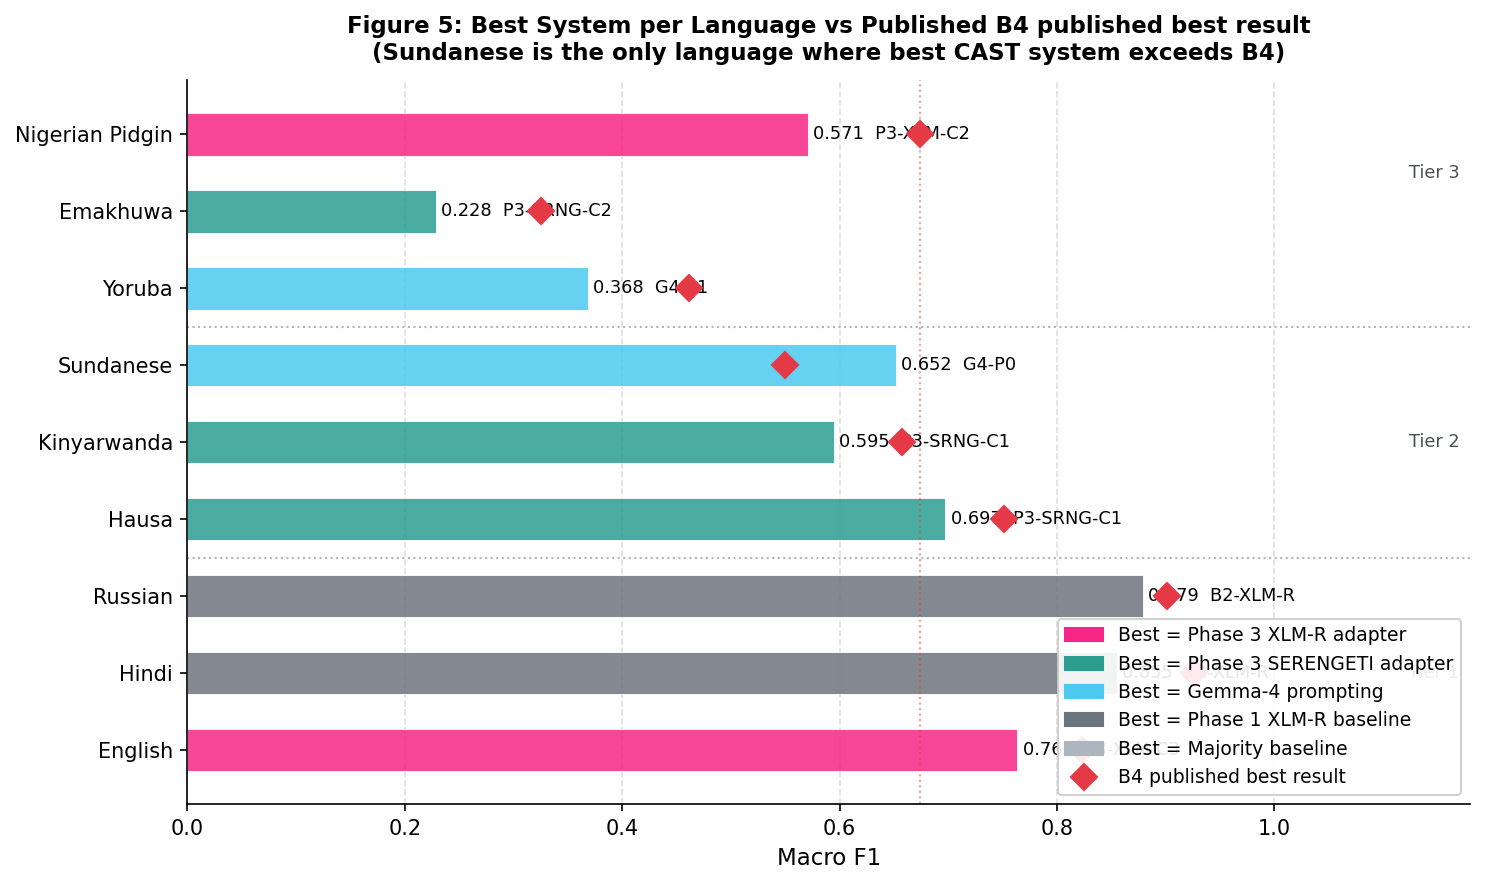

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST - Fig 5: Best System per Language
# ─────────────────────────────────────────────────────────────────────────────

best_df = build_best_system_fallback()
print("✓  Best-system table rebuilt from current raw result files.")

# Sort by tier then language order
y = np.arange(len(LANG_ORDER))

# Colour by winning system type
def system_color(name):
    if name is None or (isinstance(name, float) and np.isnan(name)):
        return "#6c757d"
    name = str(name)
    if "P3-SRNG" in name: return "#2a9d8f"
    if "P3-XLM" in name: return "#f72585"
    if "G4"    in name: return "#4cc9f0"
    if "B1"    in name: return "#adb5bd"
    if "B2"    in name: return "#6c757d"
    return "#adb5bd"

fig, ax = plt.subplots(figsize=(10, 6))

# Get values
if "Best F1" in best_df.columns:
    f1_col = "Best F1"
elif "Best_F1" in best_df.columns:
    f1_col = "Best_F1"
else:
    f1_col = best_df.columns[2]

if "Language" in best_df.columns:
    best_df = best_df.set_index("Language") if best_df.index.dtype == object and "Language" not in best_df.index.name else best_df

b4_vals  = [PUBLISHED_B4[c] for c in LANG_ORDER]

for i, code in enumerate(LANG_ORDER):
    lang   = LANGUAGES[code]["name"]
    row    = best_df[best_df["Language"]==lang].iloc[0] if "Language" in best_df.columns else best_df.iloc[i]
    f1_val = float(row.get(f1_col, row.iloc[2]))
    sys_nm = str(row.get("Best System", row.get("Best_System", "?")))
    color  = system_color(sys_nm)

    ax.barh(i, f1_val, 0.55, color=color, alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.plot(b4_vals[i], i, "D", color="#e63946", markersize=9, zorder=5)
    ax.text(f1_val + 0.005, i, f"{f1_val:.3f}  {sys_nm}", va="center", fontsize=8.5)

ax.set_yticks(y)
ax.set_yticklabels(LANG_NAMES, fontsize=10)
ax.set_xlabel("Macro F1", fontsize=11)
ax.set_xlim(0, 1.18)
ax.axvline(x=np.mean(b4_vals), color="#e63946", linestyle=":", linewidth=1, alpha=0.5)

# Tier dividers
ax.axhline(y=2.5, color="#adb5bd", linewidth=1, linestyle=":")
ax.axhline(y=5.5, color="#adb5bd", linewidth=1, linestyle=":")
for tier_y, label in [(1,"Tier 1"),(4,"Tier 2"),(7.5,"Tier 3")]:
    ax.text(1.17, tier_y, label, ha="right", va="center", fontsize=8.5, color="#495057")

# Legend
legend_patches = [
    mpatches.Patch(color="#f72585", label="Best = Phase 3 XLM-R adapter"),
    mpatches.Patch(color="#2a9d8f", label="Best = Phase 3 SERENGETI adapter"),
    mpatches.Patch(color="#4cc9f0", label="Best = Gemma-4 prompting"),
    mpatches.Patch(color="#6c757d", label="Best = Phase 1 XLM-R baseline"),
    mpatches.Patch(color="#adb5bd", label="Best = Majority baseline"),
    plt.Line2D([0],[0], marker="D", color="#e63946", linewidth=0, markersize=9, label="B4 published best result"),
]

ax.legend(handles=legend_patches, fontsize=9, loc="lower right", framealpha=0.9)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.set_title("Figure 5: Best System per Language vs Published B4 published best result\n"
             "(Sundanese is the only language where best CAST system exceeds B4)",
             fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()

path = f"{OUT_DIR}/fig5_best_system_summary.png"
fig.savefig(path, dpi=200, bbox_inches="tight")

print(f"  ✓ Saved fig5_best_system_summary.png")
plt.show()


## 5.8 Figure 6a — Per-emotion XLM-R performance


  ✓ Saved fig6_per_emotion_heatmap.png


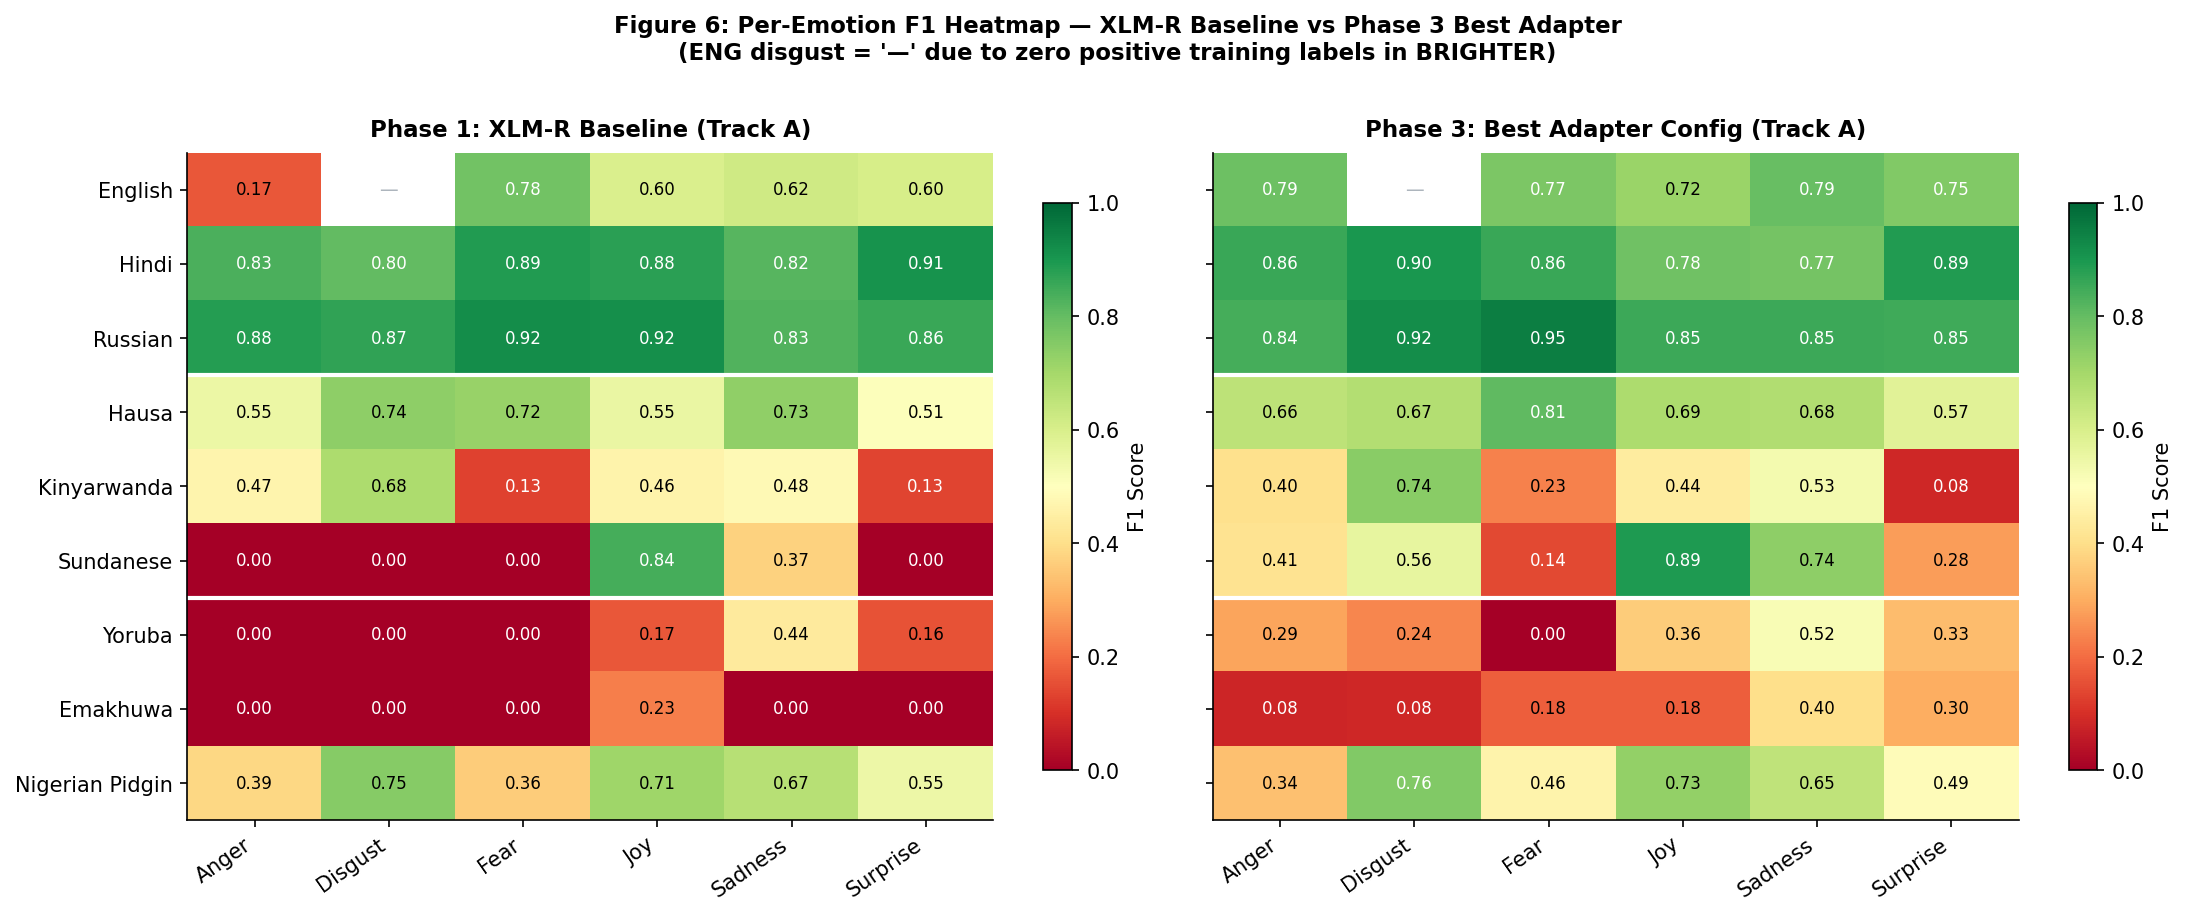

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST - Fig 6: Per-Emotion F1 Heatmap
# Two panels: XLM-R Track A baseline (left) and best P3A (right)
# ─────────────────────────────────────────────────────────────────────────────

# Build emotion matrices
def build_emo_matrix(source_fn, configs=None):
    """source_fn(code, emotion) → float|None"""
    M = np.full((len(LANG_ORDER), len(EMOTION_ORDER)), np.nan)
    for i, code in enumerate(LANG_ORDER):
        for j, emo in enumerate(EMOTION_ORDER):
            v = source_fn(code, emo)
            if v is not None:
                M[i, j] = v
    return M

# Panel A: XLM-R Phase 1 Track A per-emotion
def xlmr_p1(code, emo):
    return get_p1("xlmr", "track_a", code, emo)

# Panel B: Best P3A per-emotion (best config)
def p3a_best_emo(code, emo):
    # try C1, C2, C3 and take from whichever gives best macro_f1
    best_cfg = master.loc[master["code"]==code, "p3a_best_label"].values
    if len(best_cfg) == 0 or best_cfg[0] is None or (isinstance(best_cfg[0],float) and np.isnan(best_cfg[0])):
        return None
    return get_p3a(code, str(best_cfg[0]), emo)

M_b2   = build_emo_matrix(xlmr_p1)
M_p3a  = build_emo_matrix(p3a_best_emo)

# Cap ENG disgust at NaN
eng_idx  = LANG_ORDER.index("eng")
dis_idx  = EMOTION_ORDER.index("disgust")
M_b2 [eng_idx, dis_idx] = np.nan
M_p3a[eng_idx, dis_idx] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
subplot_titles = [
    "Phase 1: XLM-R Baseline (Track A)",
    "Phase 3: Best Adapter Config (Track A)",
]

for ax, M, title in zip(axes, [M_b2, M_p3a], subplot_titles):
    im = ax.imshow(M, cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")

    ax.set_xticks(range(len(EMOTION_ORDER)))
    ax.set_xticklabels([e.capitalize() for e in EMOTION_ORDER], rotation=35, ha="right", fontsize=10)
    ax.set_yticks(range(len(LANG_ORDER)))
    ax.set_yticklabels(LANG_NAMES, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)

    # Annotate cells
    for i in range(len(LANG_ORDER)):
        for j in range(len(EMOTION_ORDER)):
            v = M[i, j]
            if not np.isnan(v):
                tc = "white" if (v > 0.75 or v < 0.15) else "black"
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=tc)
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="#adb5bd")

    # Tier dividers
    ax.axhline(y=2.5, color="white", linewidth=2)
    ax.axhline(y=5.5, color="white", linewidth=2)
    plt.colorbar(im, ax=ax, shrink=0.85, label="F1 Score")

fig.suptitle("Figure 6: Per-Emotion F1 Heatmap — XLM-R Baseline vs Phase 3 Best Adapter\n"
             "(ENG disgust = '—' due to zero positive training labels in BRIGHTER)",
             fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
path = f"{OUT_DIR}/fig6_per_emotion_heatmap.png"
fig.savefig(path, dpi=200, bbox_inches="tight")

print(f"  ✓ Saved fig6_per_emotion_heatmap.png")
plt.show()


## Fig 6 (Track C): Per-Emotion Heatmap

  ✓ Saved fig6_track_c_per_emotion_heatmap.png


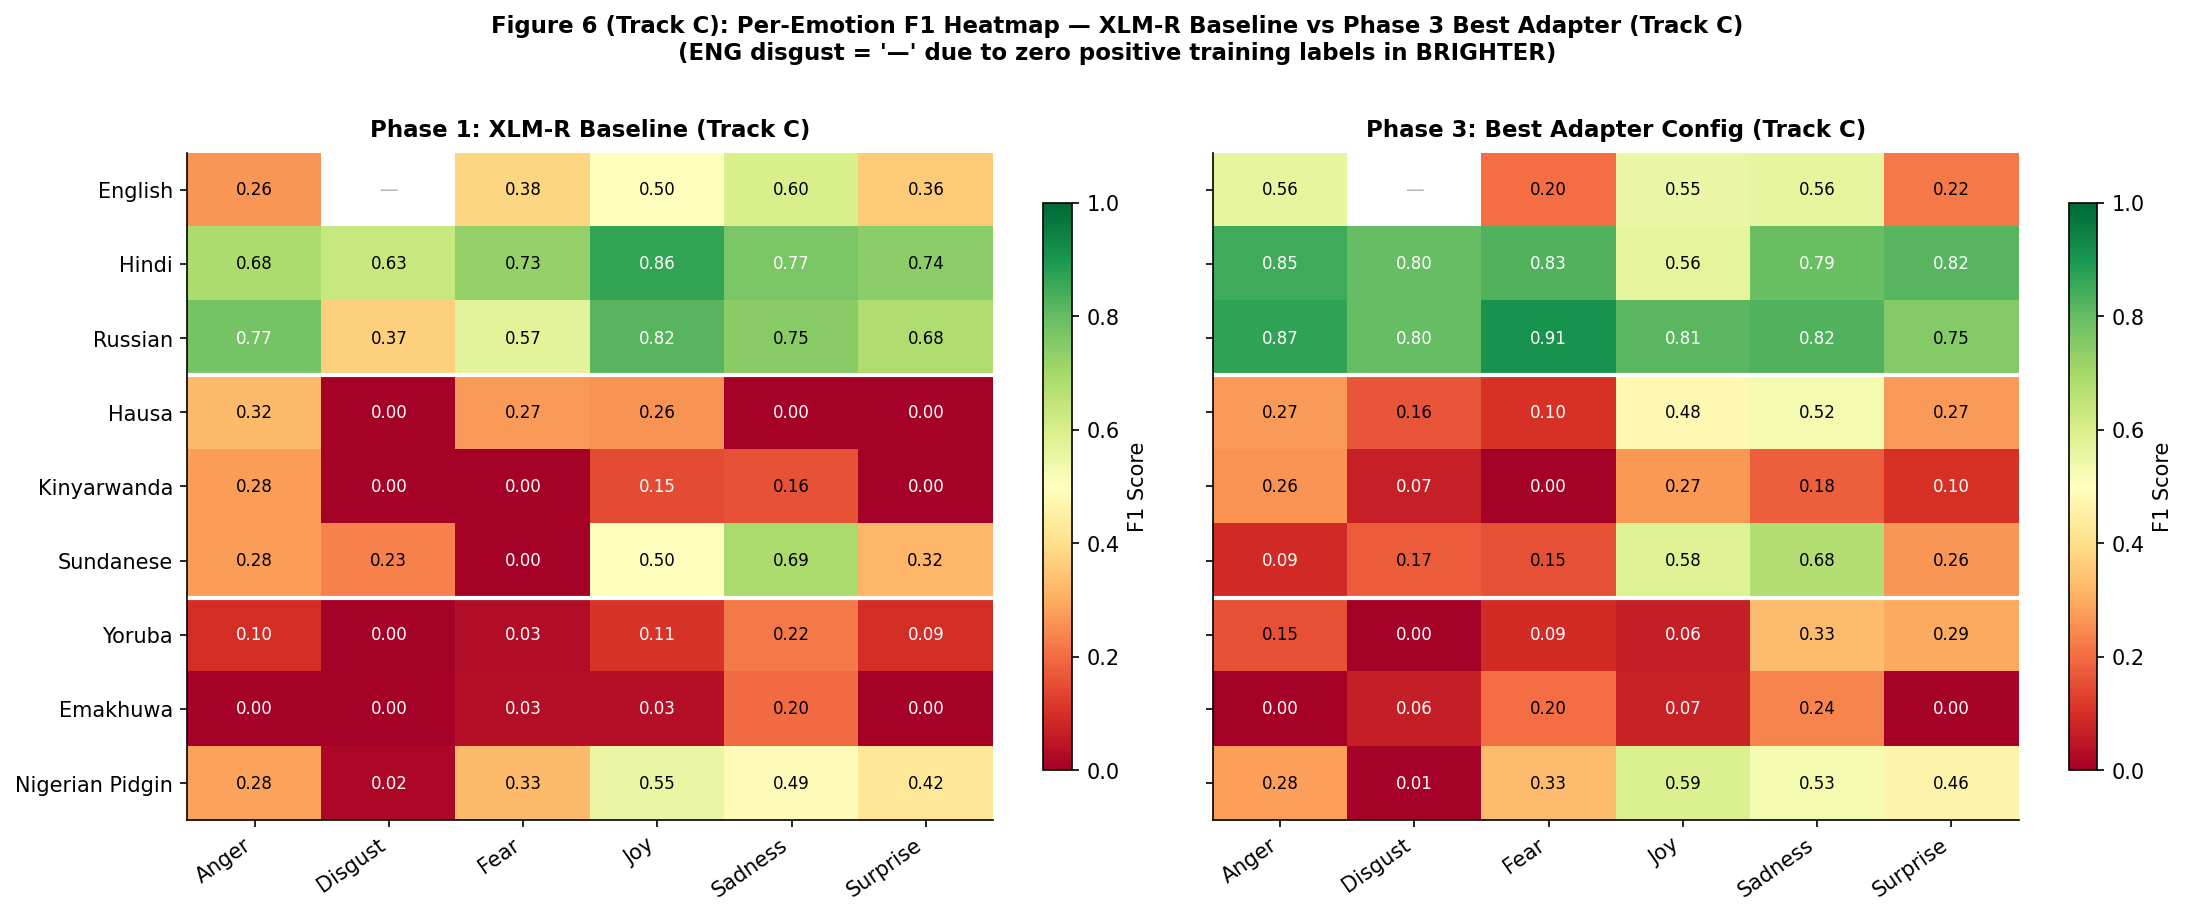

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST — Fig 6 (Track C): Per-Emotion F1 Heatmap — Track C
# XLM-R Track C baseline (left) and best P3C config (right)
# ─────────────────────────────────────────────────────────────────────────────

def xlmr_p1_tc(code, emo):
    return get_p1("xlmr", "track_c", code, emo)

def p3c_best_emo(code, emo):
    best_cfg = master.loc[master["code"]==code, "p3c_best_label"].values
    if len(best_cfg) == 0 or best_cfg[0] is None or (isinstance(best_cfg[0], float) and np.isnan(best_cfg[0])):
        return None
    return get_p3c(code, str(best_cfg[0]), emo)

M_b2_tc  = build_emo_matrix(xlmr_p1_tc)
M_p3c    = build_emo_matrix(p3c_best_emo)

eng_idx = LANG_ORDER.index("eng")
dis_idx = EMOTION_ORDER.index("disgust")
M_b2_tc[eng_idx, dis_idx] = np.nan
M_p3c  [eng_idx, dis_idx] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

subplot_titles = [
    "Phase 1: XLM-R Baseline (Track C)",
    "Phase 3: Best Adapter Config (Track C)",
]

for ax, M, title in zip(axes, [M_b2_tc, M_p3c], subplot_titles):
    im = ax.imshow(M, cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
    ax.set_xticks(range(len(EMOTION_ORDER)))
    ax.set_xticklabels([e.capitalize() for e in EMOTION_ORDER], rotation=35, ha="right", fontsize=10)
    ax.set_yticks(range(len(LANG_ORDER)))
    ax.set_yticklabels(LANG_NAMES, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    for i in range(len(LANG_ORDER)):
        for j in range(len(EMOTION_ORDER)):
            v = M[i, j]
            if not np.isnan(v):
                tc_col = "white" if (v > 0.75 or v < 0.15) else "black"
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=tc_col)
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="#adb5bd")

    ax.axhline(y=2.5, color="white", linewidth=2)
    ax.axhline(y=5.5, color="white", linewidth=2)
    plt.colorbar(im, ax=ax, shrink=0.85, label="F1 Score")

fig.suptitle("Figure 6 (Track C): Per-Emotion F1 Heatmap — XLM-R Baseline vs Phase 3 Best Adapter (Track C)\n"
             "(ENG disgust = '—' due to zero positive training labels in BRIGHTER)",
             fontsize=11, fontweight="bold", y=1.01)

plt.tight_layout()

path = f"{OUT_DIR}/fig6_track_c_per_emotion_heatmap.png"

fig.savefig(path, dpi=200, bbox_inches="tight")

print(f"  ✓ Saved fig6_track_c_per_emotion_heatmap.png")
plt.show()


## 5.9 Figure 6b - Sundanese per-emotion performance


Saved: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Visualisations/fig6b_sundanese_per_emotion.png


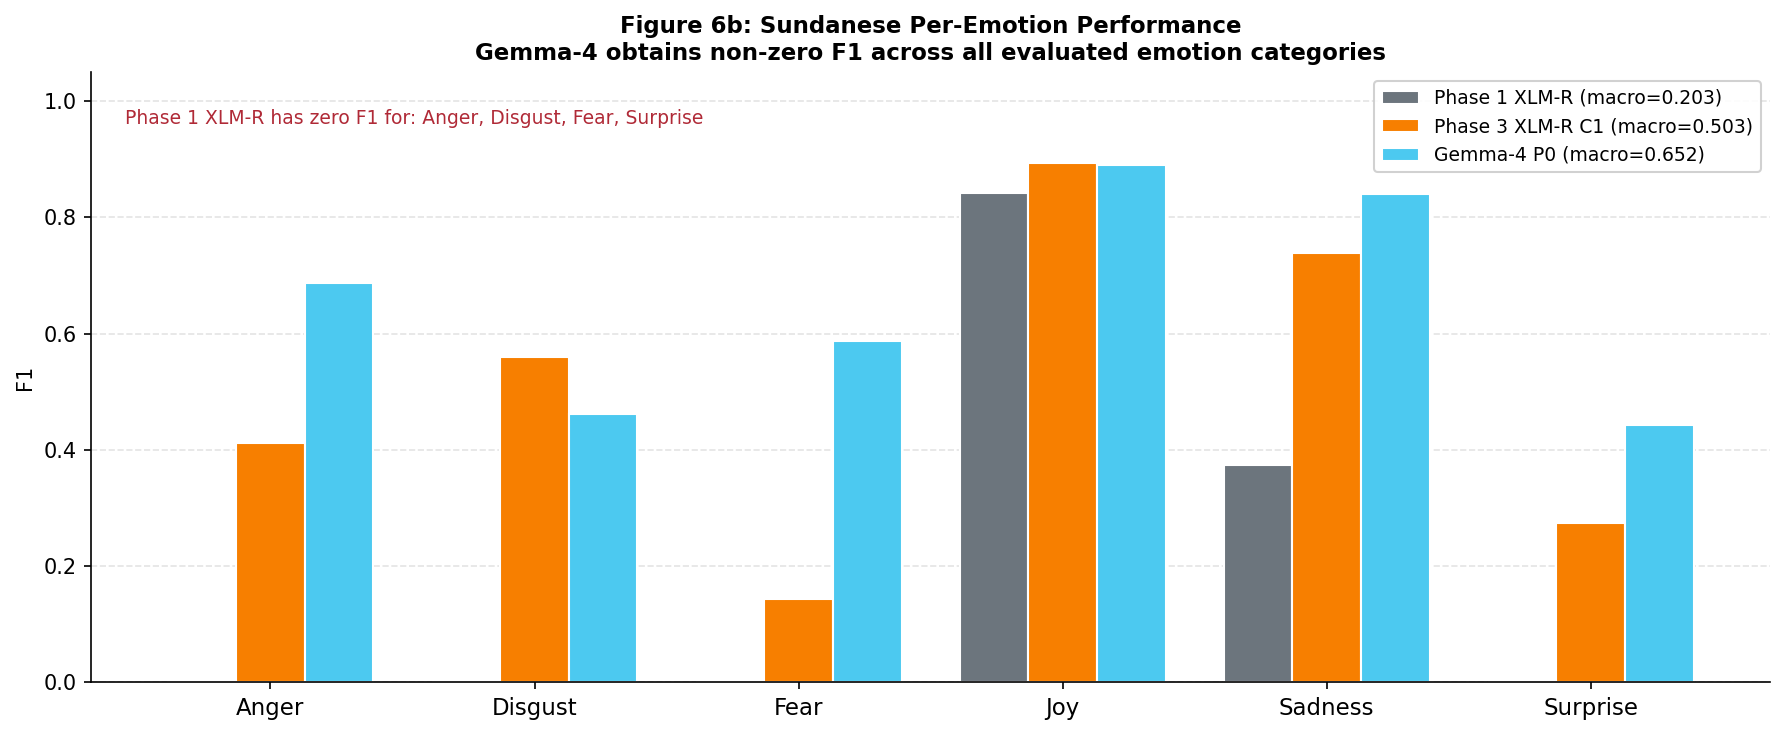

 Emotion  Phase 1 XLM-R  Phase 3 XLM-R C1  Gemma-4 P0
   Anger         0.0000            0.4118      0.6875
 Disgust         0.0000            0.5600      0.4615
    Fear         0.0000            0.1429      0.5882
     Joy         0.8418            0.8933      0.8897
 Sadness         0.3740            0.7381      0.8395
Surprise         0.0000            0.2750      0.4430


In [ ]:
emotions = ["anger", "disgust", "fear", "joy", "sadness", "surprise"]
emotion_labels = [emotion.capitalize() for emotion in emotions]

sun_xlmr = [
    get_p1("xlmr", "track_a", "sun", emotion) or 0
    for emotion in emotions
]

sun_p3 = [
    get_p3a("sun", "C1", emotion) or 0
    for emotion in emotions
]

sun_gemma = [
    get_canonical_p0("sun", emotion) or 0
    for emotion in emotions
]

figure_path = f"{OUT_DIR}/fig6b_sundanese_per_emotion.png"

if should_generate(figure_path):
    x = np.arange(len(emotions))
    width = 0.26
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(
        x - width,
        sun_xlmr,
        width,
        label=f"Phase 1 XLM-R (macro={get_p1('xlmr', 'track_a', 'sun'):.3f})",
        color="#6c757d",
        edgecolor="white",
    )
    ax.bar(
        x,
        sun_p3,
        width,
        label=f"Phase 3 XLM-R C1 (macro={get_p3a('sun', 'C1'):.3f})",
        color="#f77f00",
        edgecolor="white",
    )
    ax.bar(
        x + width,
        sun_gemma,
        width,
        label=f"Gemma-4 P0 (macro={get_canonical_p0('sun'):.3f})",
        color="#4cc9f0",
        edgecolor="white",
    )

    zero_f1_labels = [
        label for label, value in zip(emotion_labels, sun_xlmr)
        if value < 0.001
    ]
    ax.text(
        0.02,
        0.94,
        "Phase 1 XLM-R has zero F1 for: "
        + ", ".join(zero_f1_labels),
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        color="#b02a37",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(emotion_labels, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1")
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, framealpha=0.9)

    ax.set_title(
        "Figure 6b: Sundanese Per-Emotion Performance\n"
        "Gemma-4 obtains non-zero F1 across all evaluated emotion categories",
        fontsize=11,
        fontweight="bold",
    )

    plt.tight_layout()
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {figure_path}")
    plt.show()

per_emotion_table = pd.DataFrame({
    "Emotion": emotion_labels,
    "Phase 1 XLM-R": sun_xlmr,
    "Phase 3 XLM-R C1": sun_p3,
    "Gemma-4 P0": sun_gemma,
})

print(per_emotion_table.to_string(index=False))


## Fig 6b (Track C): Sundanese Per-Emotion

Saved: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Visualisations/fig6b_track_c_sundanese_per_emotion.png


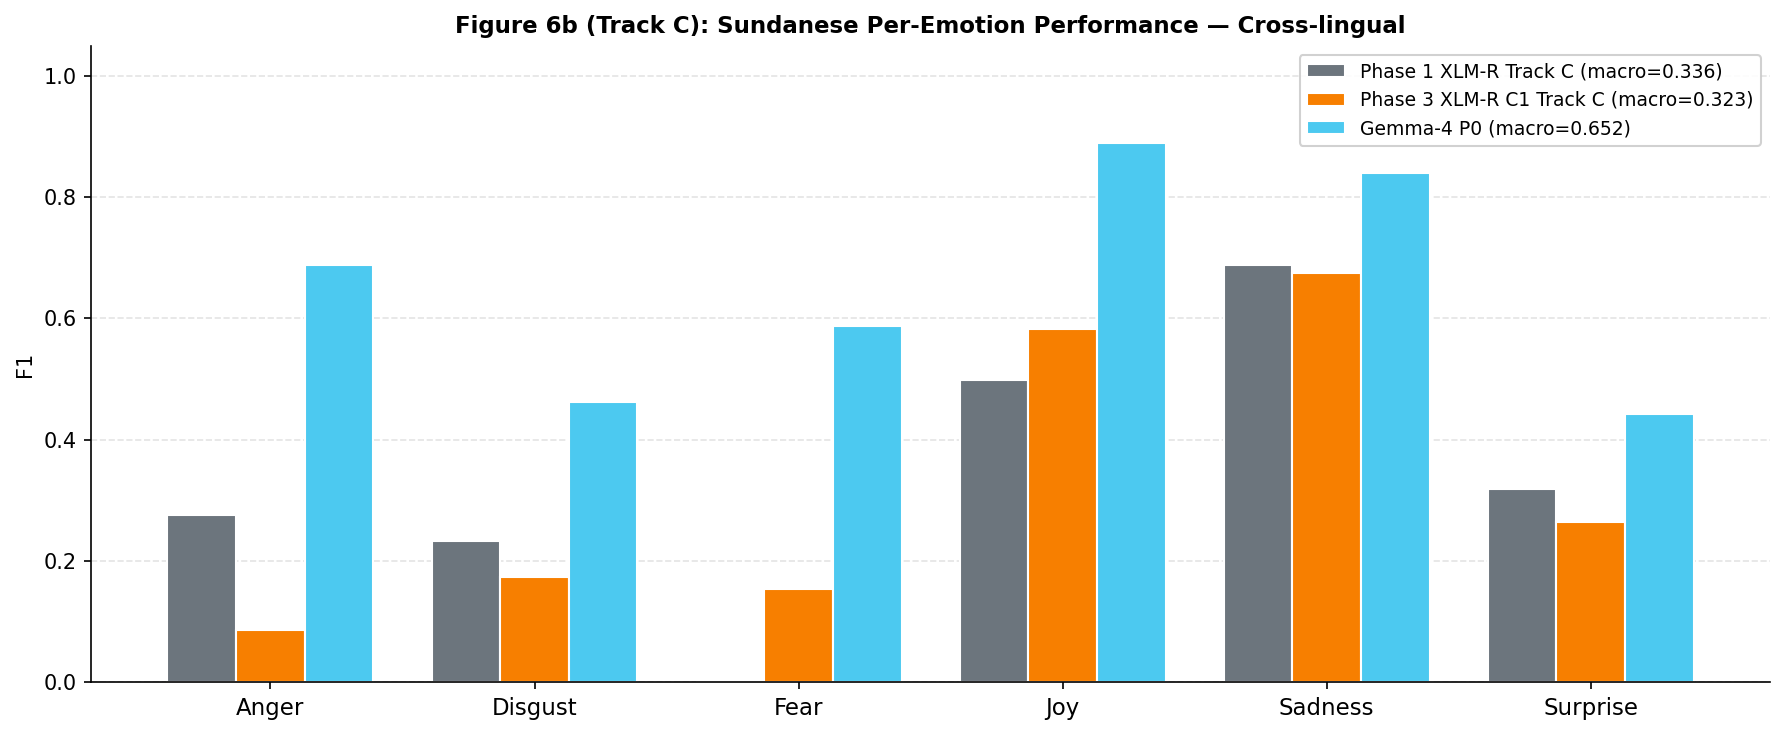

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST — Fig 6b (Track C): Sundanese Per-Emotion - Cross-lingual
# ─────────────────────────────────────────────────────────────────────────────

emotions       = ["anger", "disgust", "fear", "joy", "sadness", "surprise"]
emotion_labels = [e.capitalize() for e in emotions]

sun_xlmr_tc = [get_p1("xlmr", "track_c", "sun", e) or 0 for e in emotions]
sun_p3c     = [get_p3c("sun", "C1", e) or 0             for e in emotions]
sun_gemma   = [get_canonical_p0("sun", e) or 0           for e in emotions]

figure_path_sun_tc = f"{OUT_DIR}/fig6b_track_c_sundanese_per_emotion.png"
if should_generate(figure_path_sun_tc):
    x = np.arange(len(emotions))
    width = 0.26
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, sun_xlmr_tc, width, label=f"Phase 1 XLM-R Track C (macro={get_p1('xlmr','track_c','sun'):.3f})",
           color="#6c757d", edgecolor="white")
    ax.bar(x,          sun_p3c,     width, label=f"Phase 3 XLM-R C1 Track C (macro={get_p3c('sun','C1'):.3f})",
           color="#f77f00", edgecolor="white")
    ax.bar(x + width,  sun_gemma,   width, label=f"Gemma-4 P0 (macro={get_canonical_p0('sun'):.3f})",
           color="#4cc9f0", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(emotion_labels, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1")
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.set_title("Figure 6b (Track C): Sundanese Per-Emotion Performance — Cross-lingual",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    fig.savefig(figure_path_sun_tc, dpi=200, bbox_inches="tight")
    print(f"Saved: {figure_path_sun_tc}")
    plt.show()


## 5.10 Figure 7 — Track A versus Track C


  ✓ Saved fig7_track_a_vs_c_gap.png


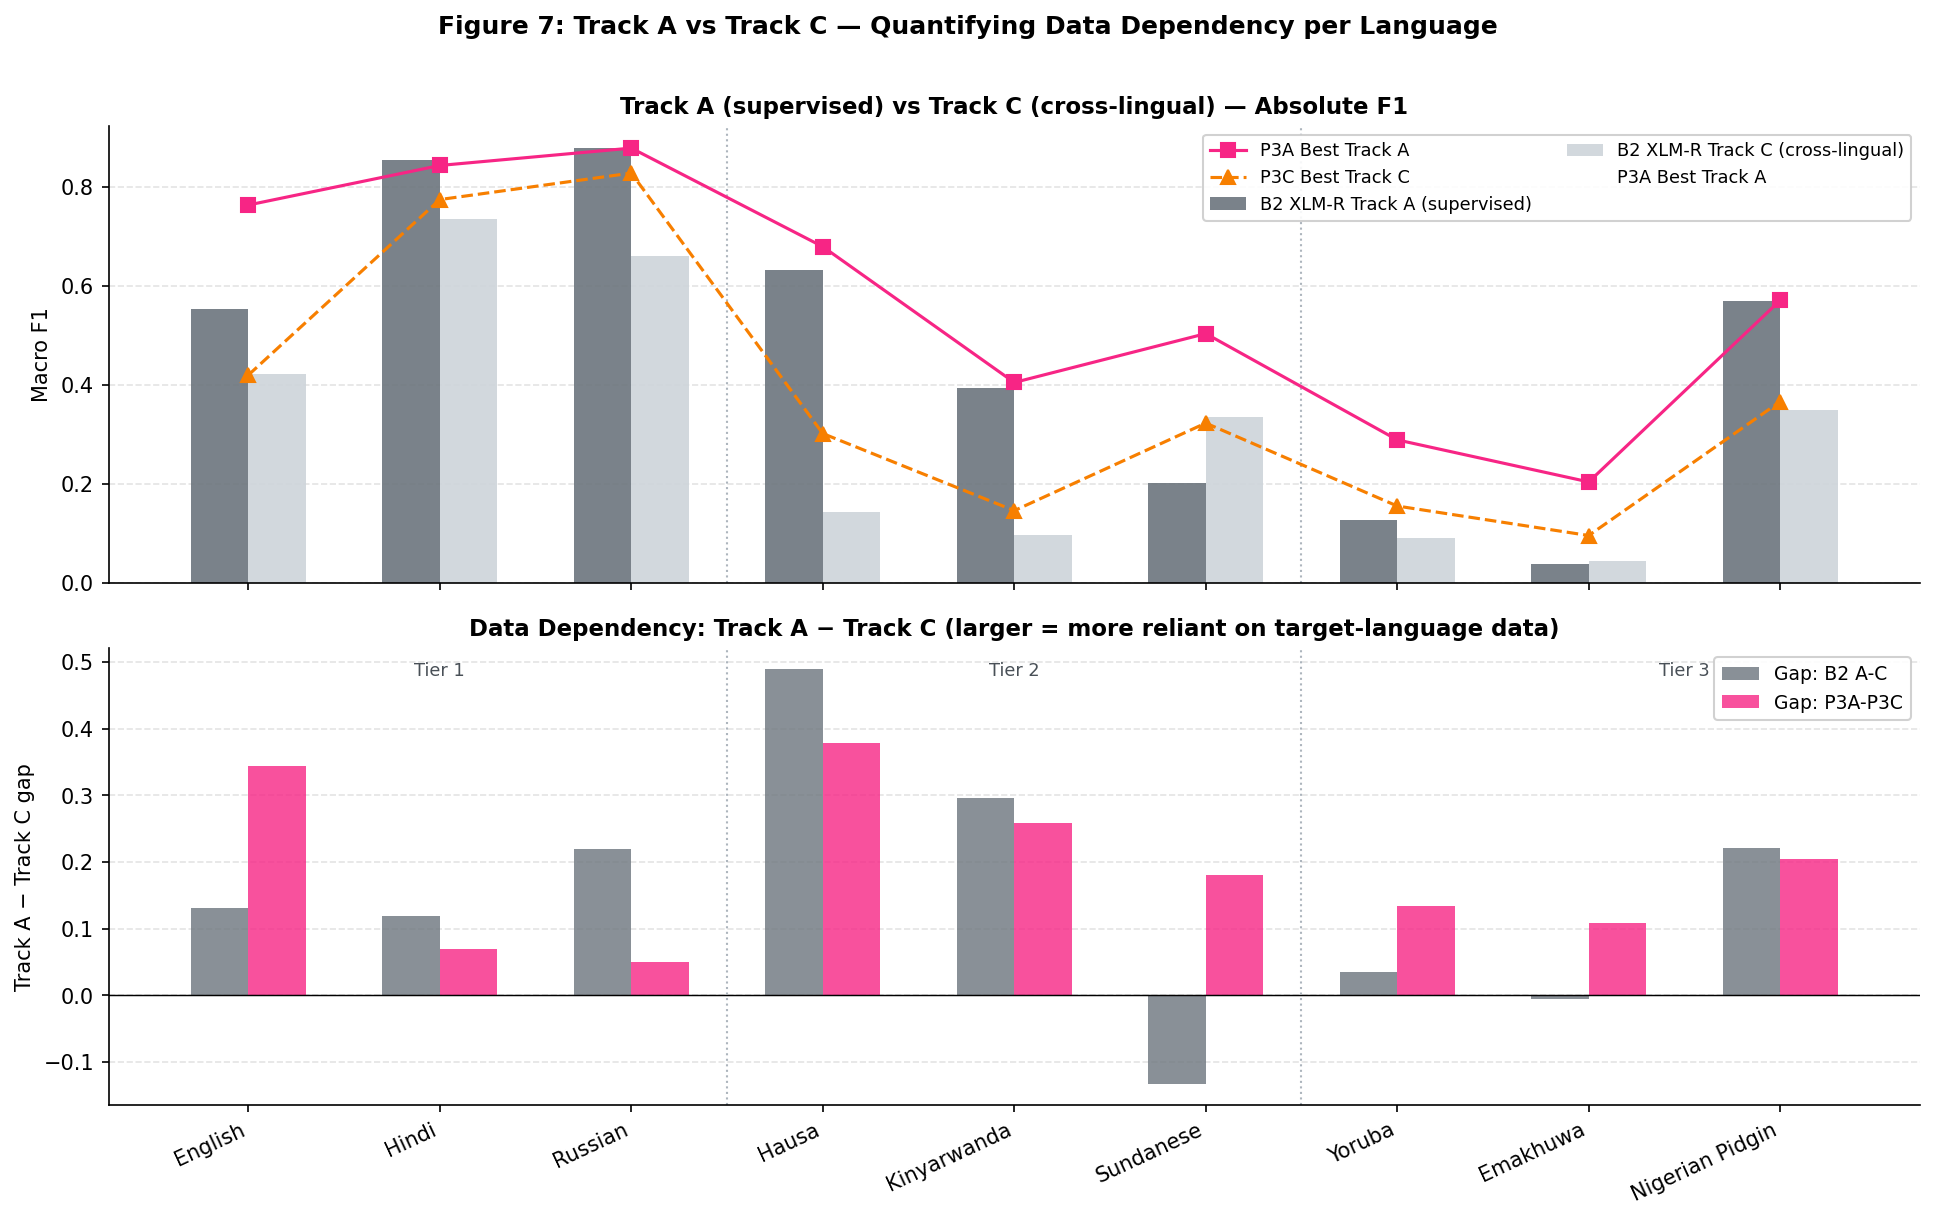

  Hausa B2 Track A→C drop: 0.633 → 0.143  (Δ = +0.490)
  Sundanese B2 Track A→C:  0.203 → 0.336  (effectively no change)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST - Fig 7: Track A vs Track C Gap
# ─────────────────────────────────────────────────────────────────────────────

# For each language: B2 Track A, B2 Track C, P3A best Track A, P3C best Track C
ta_b2, tc_b2, ta_p3, tc_p3 = [], [], [], []

for code in LANG_ORDER:
    ta_b2.append(get_p1("xlmr","track_a",code) or 0)
    tc_b2.append(get_p1("xlmr","track_c",code) or 0)

    # P3A best
    p3a_scores = {c: get_p3a(code,c) for c in ["C1","C2","C3"] if get_p3a(code,c) is not None}
    ta_p3.append(max(p3a_scores.values()) if p3a_scores else 0)

    # P3C best
    p3c_scores = {c: get_p3c(code,c) for c in ["C1","C2","C3"] if get_p3c(code,c) is not None}
    tc_p3.append(max(p3c_scores.values()) if p3c_scores else 0)

ta_b2 = np.array(ta_b2);  tc_b2 = np.array(tc_b2)
ta_p3 = np.array(ta_p3);  tc_p3 = np.array(tc_p3)
gaps_b2 = ta_b2 - tc_b2
gaps_p3 = ta_p3 - tc_p3

x = np.arange(len(LANG_ORDER))
w = 0.30

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# ── Top: Track A vs Track C absolute values ───────────────────────────────────
ax1.bar(x-w/2, ta_b2, w, label="B2 XLM-R Track A (supervised)", color="#6c757d", alpha=0.9)
ax1.bar(x+w/2, tc_b2, w, label="B2 XLM-R Track C (cross-lingual)", color="#ced4da", alpha=0.9)
ax1.bar(x-w/2, ta_p3, w, bottom=0, label="P3A Best Track A", color="#f72585", alpha=0.0)  # placeholder
ax1.plot(x, ta_p3, "s-", color="#f72585", linewidth=1.5, markersize=7, label="P3A Best Track A", zorder=5)
ax1.plot(x, tc_p3, "^--", color="#f77f00", linewidth=1.5, markersize=7, label="P3C Best Track C", zorder=5)

ax1.axvline(2.5, color="#adb5bd", linewidth=1, linestyle=":")
ax1.axvline(5.5, color="#adb5bd", linewidth=1, linestyle=":")
ax1.set_ylabel("Macro F1", fontsize=10)
ax1.set_title("Track A (supervised) vs Track C (cross-lingual) — Absolute F1", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8.5, loc="upper right", ncol=2, framealpha=0.9)
ax1.yaxis.grid(True, linestyle="--", alpha=0.35)
ax1.set_axisbelow(True)

# ── Bottom: Track A – Track C gap  ───────────────
bar_colors = [TIER_COLORS[LANGUAGES[c]["tier"]] for c in LANG_ORDER]
bars = ax2.bar(x-w/2, gaps_b2, w, label="Gap: B2 A-C", color="#6c757d", alpha=0.8)
bars = ax2.bar(x+w/2, gaps_p3, w, label="Gap: P3A-P3C", color="#f72585", alpha=0.8)
ax2.axhline(0, color="black", linewidth=0.7)
ax2.axvline(2.5, color="#adb5bd", linewidth=1, linestyle=":")
ax2.axvline(5.5, color="#adb5bd", linewidth=1, linestyle=":")
ax2.set_ylabel("Track A − Track C gap", fontsize=10)
ax2.set_title("Data Dependency: Track A − Track C (larger = more reliant on target-language data)", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9, framealpha=0.9)
ax2.yaxis.grid(True, linestyle="--", alpha=0.35)
ax2.set_axisbelow(True)

ax2.set_xticks(x)
ax2.set_xticklabels(LANG_NAMES, rotation=25, ha="right", fontsize=10)

for tier_x, label in [(1,"Tier 1"),(4,"Tier 2"),(7.5,"Tier 3")]:
    ax2.text(tier_x, ax2.get_ylim()[1]*0.92, label, ha="center", fontsize=8.5, color="#495057")

fig.suptitle("Figure 7: Track A vs Track C — Quantifying Data Dependency per Language",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
path = f"{OUT_DIR}/fig7_track_a_vs_c_gap.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
print(f"  ✓ Saved fig7_track_a_vs_c_gap.png")
plt.show()

# Print Hausa's notorious drop as a callout
hau_idx = LANG_ORDER.index("hau")
print(f"  Hausa B2 Track A→C drop: {ta_b2[hau_idx]:.3f} → {tc_b2[hau_idx]:.3f}  (Δ = {gaps_b2[hau_idx]:+.3f})")
print(f"  Sundanese B2 Track A→C:  {ta_b2[LANG_ORDER.index('sun')]:.3f} → {tc_b2[LANG_ORDER.index('sun')]:.3f}  (effectively no change)")


## 5.11 Figure 8 - Transfer-pool results by resource tier


  ✓ Saved fig8_subfamily_hypothesis.png


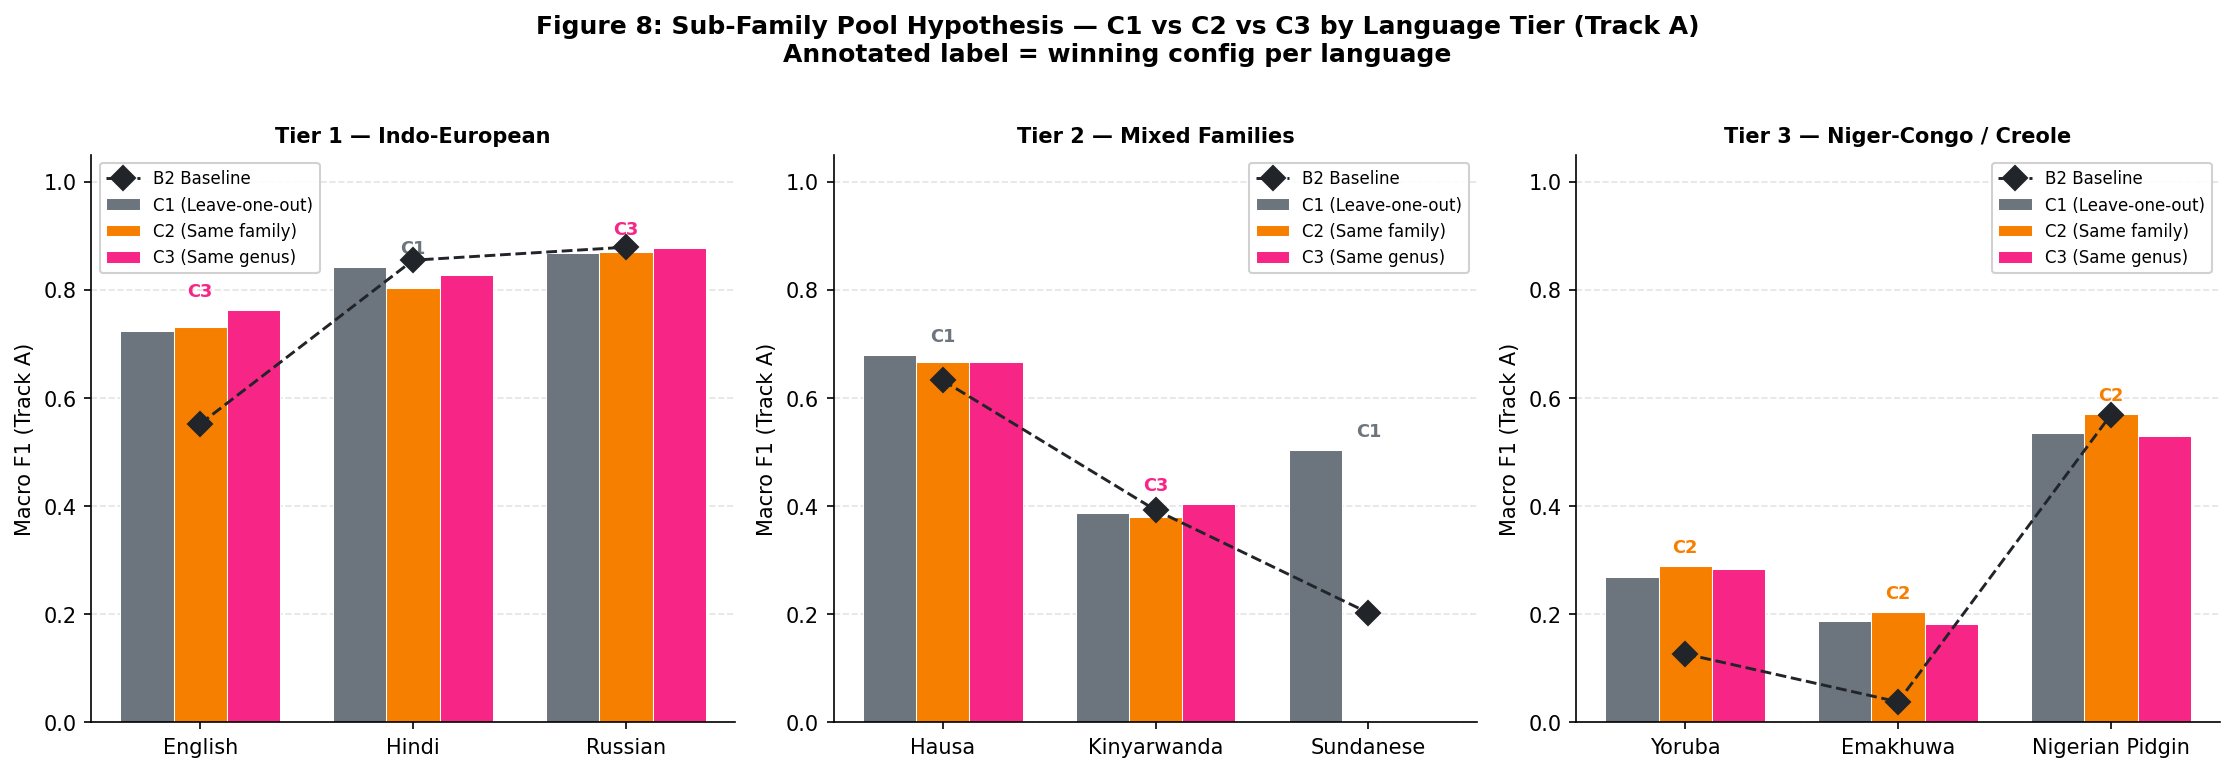


  Sub-family hypothesis verdict (Track A):
  English             C1=0.724  C2=0.731  C3=0.763  → C3  ← C3 wins
  Hindi               C1=0.843  C2=0.803  C3=0.828  → C1  
  Russian             C1=0.868  C2=0.870  C3=0.878  → C3  ← C3 wins
  Hausa               C1=0.679  C2=0.668  C3=0.668  → C1  
  Kinyarwanda         C1=0.388  C2=0.380  C3=0.405  → C3  ← C3 wins
  Sundanese           C1=0.503  → C1  
  Yoruba              C1=0.269  C2=0.289  C3=0.283  → C2  
  Emakhuwa            C1=0.187  C2=0.204  C3=0.182  → C2  
  Nigerian Pidgin     C1=0.535  C2=0.571  C3=0.529  → C2  

  C3 wins in 3/9 languages (Track A)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST — Fig 8: Sub-Family Hypothesis — C1 vs C2 vs C3
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
tier_langs = {1: ["eng","hin","rus"], 2: ["hau","kin","sun"], 3: ["yor","vmw","pcm"]}
tier_titles = {
    1: "Tier 1 — Indo-European",
    2: "Tier 2 — Mixed Families",
    3: "Tier 3 — Niger-Congo / Creole",
}
cfg_colors = {"C1":"#6c757d","C2":"#f77f00","C3":"#f72585"}
cfg_labels = {"C1":"C1 (Leave-one-out)","C2":"C2 (Same family)","C3":"C3 (Same genus)"}

for col_idx, (tier, lang_list) in enumerate(tier_langs.items()):
    ax = axes[col_idx]
    x_local = np.arange(len(lang_list))
    w_local = 0.25

    for j, cfg in enumerate(["C1","C2","C3"]):
        vals = []
        for code in lang_list:
            v = get_p3a(code, cfg)
            vals.append(v if v is not None else 0.0)
        ax.bar(x_local + (j-1)*w_local, vals, w_local,
               label=cfg_labels[cfg], color=cfg_colors[cfg], edgecolor="white", linewidth=0.5)

    # B2 baseline line
    b2_baseline = [get_p1("xlmr","track_a",code) or 0 for code in lang_list]
    ax.plot(x_local, b2_baseline, "D--", color="#212529", markersize=8,
            linewidth=1.4, label="B2 Baseline", zorder=5)

    ax.set_xticks(x_local)
    ax.set_xticklabels([LANGUAGES[c]["name"] for c in lang_list], fontsize=10)
    ax.set_ylabel("Macro F1 (Track A)", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_title(tier_titles[tier], fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="best", framealpha=0.9)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    # Annotate winning config per language
    for k, code in enumerate(lang_list):
        scores = {c: (get_p3a(code,c) or 0) for c in ["C1","C2","C3"]}
        winner = max(scores, key=scores.get)
        winner_val = scores[winner]
        if winner_val > 0:
            ax.text(k, winner_val + 0.025, winner, ha="center", fontsize=8.5,
                    color=cfg_colors[winner], fontweight="bold")

fig.suptitle("Figure 8: Sub-Family Pool Hypothesis — C1 vs C2 vs C3 by Language Tier (Track A)\n"
             "Annotated label = winning config per language",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
path = f"{OUT_DIR}/fig8_subfamily_hypothesis.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
print(f"   Saved fig8_subfamily_hypothesis.png")
plt.show()

# ── Print the hypothesis verdict ───────────────────────────────────────────────
print("\n  Sub-family hypothesis verdict (Track A):")
c3_wins = 0
for code in LANG_ORDER:
    scores = {c: get_p3a(code,c) for c in ["C1","C2","C3"] if get_p3a(code,c) is not None}
    if not scores: continue
    winner = max(scores, key=scores.get)
    flag = " C3 wins" if winner == "C3" else ""
    if winner == "C3": c3_wins += 1
    vals_str = "  ".join(f"{c}={v:.3f}" for c,v in scores.items())
    print(f"  {LANGUAGES[code]['name']:<18}  {vals_str}  → {winner}  {flag}")
print(f"\n  C3 wins in {c3_wins}/9 languages (Track A)")


## Fig 8 (Track C): Sub-Family Hypothesis

  ✓ Saved fig8_track_c_subfamily_hypothesis.png


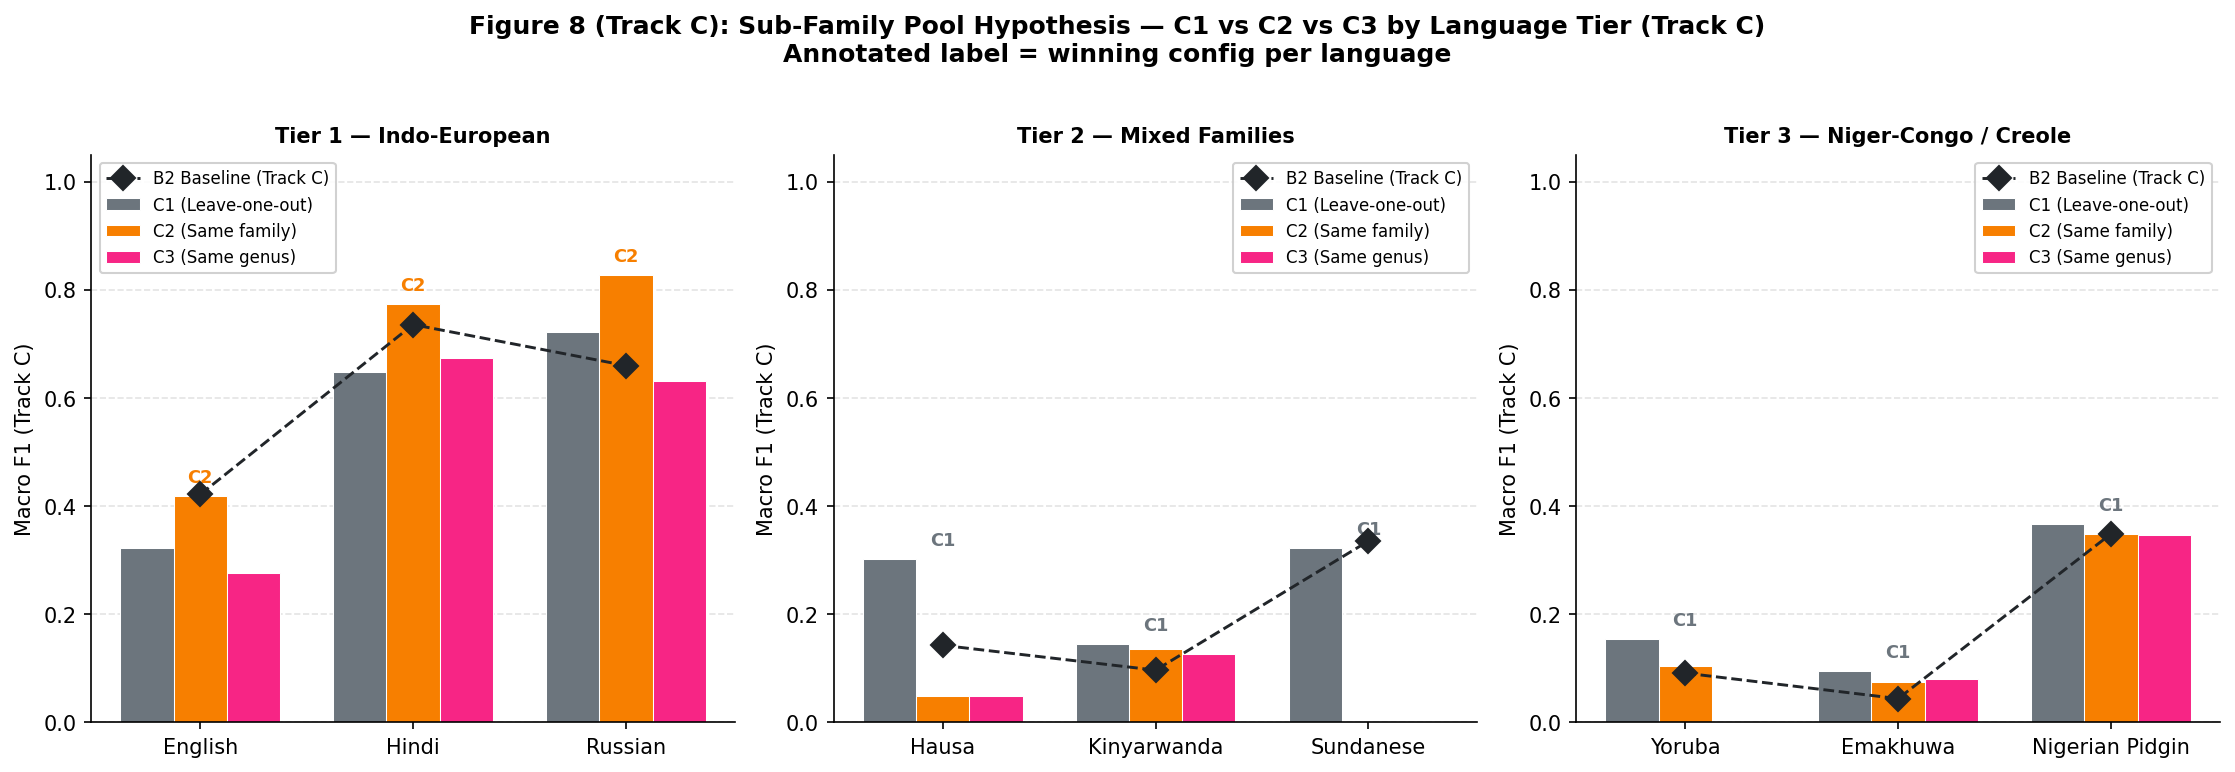


  Sub-family hypothesis verdict (Track C):
  English             C1=0.322  C2=0.420  C3=0.276  → C2
  Hindi               C1=0.647  C2=0.774  C3=0.673  → C2
  Russian             C1=0.722  C2=0.828  C3=0.631  → C2
  Hausa               C1=0.302  C2=0.048  C3=0.048  → C1
  Kinyarwanda         C1=0.146  C2=0.137  C3=0.126  → C1
  Sundanese           C1=0.323  → C1
  Yoruba              C1=0.155  C2=0.105  → C1
  Emakhuwa            C1=0.096  C2=0.076  C3=0.080  → C1
  Nigerian Pidgin     C1=0.366  C2=0.349  C3=0.346  → C1

  C3 wins in 0/9 languages (Track C)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST — Fig 8 (Track C): Sub-Family Hypothesis — C1 vs C2 vs C3 (Track C)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
tier_langs  = {1: ["eng","hin","rus"], 2: ["hau","kin","sun"], 3: ["yor","vmw","pcm"]}
tier_titles = {1:"Tier 1 — Indo-European", 2:"Tier 2 — Mixed Families", 3:"Tier 3 — Niger-Congo / Creole"}
cfg_colors  = {"C1":"#6c757d","C2":"#f77f00","C3":"#f72585"}
cfg_labels  = {"C1":"C1 (Leave-one-out)","C2":"C2 (Same family)","C3":"C3 (Same genus)"}

for col_idx, (tier, lang_list) in enumerate(tier_langs.items()):
    ax = axes[col_idx]
    x_local = np.arange(len(lang_list))
    w_local = 0.25

    for j, cfg in enumerate(["C1","C2","C3"]):
        vals = [get_p3c(code, cfg) or 0.0 for code in lang_list]
        ax.bar(x_local + (j-1)*w_local, vals, w_local,
               label=cfg_labels[cfg], color=cfg_colors[cfg], edgecolor="white", linewidth=0.5)

    b2_tc_baseline = [get_p1("xlmr","track_c",code) or 0 for code in lang_list]
    ax.plot(x_local, b2_tc_baseline, "D--", color="#212529", markersize=8,
            linewidth=1.4, label="B2 Baseline (Track C)", zorder=5)

    ax.set_xticks(x_local)
    ax.set_xticklabels([LANGUAGES[c]["name"] for c in lang_list], fontsize=10)
    ax.set_ylabel("Macro F1 (Track C)", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_title(tier_titles[tier], fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="best", framealpha=0.9)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    for k, code in enumerate(lang_list):
        scores  = {c: (get_p3c(code,c) or 0) for c in ["C1","C2","C3"]}
        winner  = max(scores, key=scores.get)
        win_val = scores[winner]
        if win_val > 0:
            ax.text(k, win_val+0.025, winner, ha="center", fontsize=8.5,
                    color=cfg_colors[winner], fontweight="bold")

fig.suptitle("Figure 8 (Track C): Sub-Family Pool Hypothesis — C1 vs C2 vs C3 by Language Tier (Track C)\n"
             "Annotated label = winning config per language",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
path = f"{OUT_DIR}/fig8_track_c_subfamily_hypothesis.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
print(f"   Saved fig8_track_c_subfamily_hypothesis.png")
plt.show()

print("\n  Sub-family hypothesis verdict (Track C):")
c3_wins_tc = 0
for code in LANG_ORDER:
    scores = {c: get_p3c(code,c) for c in ["C1","C2","C3"] if get_p3c(code,c) is not None}
    if not scores: continue
    winner = max(scores, key=scores.get)
    if winner == "C3": c3_wins_tc += 1
    vals_str = "  ".join(f"{c}={v:.3f}" for c,v in scores.items())
    print(f"  {LANGUAGES[code]['name']:<18}  {vals_str}  → {winner}")
print(f"\n  C3 wins in {c3_wins_tc}/9 languages (Track C)")


## 6.1 Phase 2 and Phase 4 significance tables


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST - Cell 13: Significance Tables for Phase 2 and Phase 4  [CORRECTED]
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 80)
print("  PHASE 2 — CULTURAL PROMPT SIGNIFICANCE RESULTS")
print("  (Source: 'prompt_only vs neither' from Phase 4 pairwise bootstrap)")
print("=" * 80)

if not p4_sig_p2.empty:
    print(p4_sig_p2.to_string(index=False))
    p4_sig_p2.to_csv(f"{OUT_DIR}/table_phase2_significance.csv", index=False)
    print(f"\n  Saved table_phase2_significance.csv")
else:
    print("  Phase 2 significance file not found at:")
    print(f"    {P4S2_PATH}")
    print("  Generate it separately and drop it there, then rerun this cell.")

print("\n\n" + "=" * 80)
print("  PHASE 4 — ABLATION SIGNIFICANCE RESULTS")
print("=" * 80)

if not p4_sig_p4.empty:
    print(p4_sig_p4.to_string(index=False))
    p4_sig_p4.to_csv(f"{OUT_DIR}/table_phase4_significance.csv", index=False)
    print(f"\n  Saved table_phase4_significance.csv")
else:
    print("  WARNING: Phase 4 ablation significance CSV not found — table skipped.")

if not p4_srng_sig.empty:
    p4_srng_sig.to_csv(
        f"{OUT_DIR}/table_phase4_serengeti_significance.csv", index=False
    )
    print("  Saved table_phase4_serengeti_significance.csv")
else:
    print("  WARNING: Phase 4 SERENGETI significance CSV not found — table skipped.")


  PHASE 2 — CULTURAL PROMPT SIGNIFICANCE RESULTS
  (Source: 'prompt_only vs neither' from Phase 4 pairwise bootstrap)
Language code        Language Prompt condition Comparison  P0 baseline macro-F1  Compared prompt macro-F1  Prompt effect (compared prompt minus P0)  95% confidence interval lower bound  95% confidence interval upper bound  Raw p-value Higher-scoring condition  Holm-adjusted p-value  Significant after Holm correction (alpha=0.05) Evaluation split                   Analysis scope
          ENG         English               p1   P0 vs P1                0.6274                    0.6112                                   -0.0162                              -0.0363                               0.0028       0.1029                       P0                 0.1690                                           False       Validation Internal Gemma prompt comparison
          ENG         English               p2   P0 vs P2                0.6274                    0.6069               

## 6.2 Phase 3 significance tables


In [ ]:
phase3_tables = {
    "table_phase3_xlmr_significance.csv": p3_xlmr_sig,
    "table_phase3_serengeti_significance.csv": p3_srng_sig,
    "table_phase3_backbone_significance.csv": p3_backbone_sig,
}

for filename, frame in phase3_tables.items():
    if frame.empty:
        raise ValueError(f"Required Phase 3 significance table is empty: {filename}")
    required = {"adjusted_p", "sig_adjusted"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"{filename} missing corrected-significance columns: {sorted(missing)}")
    output_path = f"{OUT_DIR}/{filename}"
    frame.to_csv(output_path, index=False)
    print(f"Saved {len(frame)} rows: {output_path}")


Saved 42 rows: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Visualisations/table_phase3_xlmr_significance.csv
Saved 24 rows: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Visualisations/table_phase3_serengeti_significance.csv
Saved 25 rows: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Visualisations/table_phase3_backbone_significance.csv


## 6.3 Phase 4 interaction analysis


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CAST — Cell 14: Non-Additivity Analysis (CAST = Prompt + Config interaction)
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 100)
print("  PHASE 4 — NON-ADDITIVITY ANALYSIS")
print("  Additive prediction = G4-P0 + (Prompt - G4-P0) + (Config - G4-P0)")
print("  Actual = G4-CAST;  Additivity gap = Actual - Predicted additive")
print("=" * 100)

if not p4_ablation.empty:
    abl = p4_ablation.copy()
    # Column name normalization (robust to different CSV export formats)
    for col in list(abl.columns):
        lc = col.lower()
        if "language" in lc:
            abl = abl.rename(columns={col:"Language"})
        elif "neither" in lc or ("g4" in lc and "p0" in lc and "prompt" not in lc and "config" not in lc and "cast" not in lc):
            abl = abl.rename(columns={col:"neither"})
        elif "prompt-only" in lc or "prompt only" in lc or lc == "g4-prompt":
            abl = abl.rename(columns={col:"prompt_only"})
        elif "config-only" in lc or "config only" in lc or lc == "g4-config":
            abl = abl.rename(columns={col:"config_only"})
        elif "cast" in lc and ("both" in lc or lc == "g4-cast"):
            abl = abl.rename(columns={col:"cast_both"})
        elif "additive" in lc:
            abl = abl.rename(columns={col:"additive"})

    needed = ["Language","neither","prompt_only","config_only","cast_both"]
    if all(c in abl.columns for c in needed):
        abl["additive_pred"] = (
            abl["neither"]
            + (abl["prompt_only"] - abl["neither"])
            + (abl["config_only"] - abl["neither"])
        )
        abl["additivity_gap"] = abl["cast_both"] - abl["additive_pred"]

        display_cols = ["Language","neither","prompt_only","config_only","cast_both","additive_pred","additivity_gap"]
        print(abl[display_cols].to_string(index=False, float_format="{:.4f}".format))
        print(f"\n  Positive interaction point estimates: {(abl['additivity_gap']>0.001).sum()}/9")
        print(f"  Negative interaction point estimates: {(abl['additivity_gap']<-0.001).sum()}/9")
        print(f"  Mean additivity gap: {abl['additivity_gap'].mean():.4f}")
        abl.to_csv(f"{OUT_DIR}/table_phase4_non_additivity.csv", index=False)
        print(f"\n  ✓ Saved table_phase4_non_additivity.csv")
    else:
        print(f"  Expected columns not found. Available: {list(abl.columns)}")
else:
    print("Phase 4 ablation CSV not found — rebuilding from raw result files")
    abl_manual = build_phase4_ablation_fallback()
    abl_manual["additive_pred"] = (
        abl_manual["G4-P0"]
        + (abl_manual["G4-Prompt"] - abl_manual["G4-P0"])
        + (abl_manual["G4-Config"] - abl_manual["G4-P0"])
    )
    abl_manual["additivity_gap"] = (
        abl_manual["G4-CAST"] - abl_manual["additive_pred"]
    )
    print(
        abl_manual.to_string(
            index=False,
            float_format="{:.4f}".format,
        )
    )
    print(
        "\n  All G4-P0 values above come from the canonical Phase 2 P0."
    )


# Inferential conclusions come from the bootstrap interaction files.
interaction_tables = {
    "table_phase4_interaction_significance.csv": p4_sig_interaction,
    "table_phase4_serengeti_interaction_significance.csv": p4_srng_interaction,
}

for filename, frame in interaction_tables.items():
    if frame.empty:
        raise ValueError(f"Required interaction table is empty: {filename}")
    required = {"adjusted_p", "sig_adjusted"}
    missing = required - set(frame.columns)
    if missing:
        print(f"  WARNING: {filename} missing columns {sorted(missing)} — attempting column rename")
        frame = rename_bootstrap_cols(frame)
        still_missing = required - set(frame.columns)
        if still_missing:
            print(f"  SKIPPING {filename} — columns {sorted(still_missing)} could not be resolved")
            continue
    output_path = f"{OUT_DIR}/{filename}"
    frame.to_csv(output_path, index=False)

    print(f"Saved {len(frame)} rows: {output_path}")


  PHASE 4 — NON-ADDITIVITY ANALYSIS
  Additive prediction = G4-P0 + (Prompt - G4-P0) + (Config - G4-P0)
  Actual = G4-CAST;  Additivity gap = Actual - Predicted additive
       Language  neither  prompt_only  config_only  cast_both  additive_pred  additivity_gap
        English   0.6245       0.6245       0.6290     0.6290         0.6290          0.0000
          Hausa   0.5491       0.5790       0.5317     0.5741         0.5616          0.0125
          Hindi   0.8043       0.8393       0.8384     0.8496         0.8734         -0.0238
    Kinyarwanda   0.4223       0.4417       0.4204     0.4347         0.4398         -0.0051
Nigerian Pidgin   0.5263       0.5605       0.5452     0.5650         0.5794         -0.0144
        Russian   0.8071       0.8371       0.8504     0.8559         0.8804         -0.0245
      Sundanese   0.5596       0.5596       0.5212     0.5212         0.5212          0.0000
       Emakhuwa   0.0709       0.0738       0.0612     0.0980         0.0641          